# Pollution Pattern Analysis: Identifying Air-Pollution Hotspots and Potential Source Profiles in the Netherlands

**Author:** Esmeralda Castellanos.
**Capstone challenge:** Applying Your Data Science Toolkit.
**Data:** RIVM Luchtmeetnet, 2024 annual measurements.

In [2]:
import sys
print(sys.executable)

c:\Users\caste\Documents\clustering-project-esmeralda\.venv\Scripts\python.exe


## Project Proposal: Mastering Unsupervised Learning & Clustering for Real-World Exploration

### Problem Context

Air pollution exposure in the Netherlands is not evenly distributed. Traffic density, industrial
activity, urban form, and regional weather patterns all shape how much NO2, PM2.5, PM10, and O3
a given location experiences over a year. National or provincial averages smooth over these
differences and can hide the fact that some locations face a persistently different pollution
*profile* than others  not just a different pollution *level*.

This matters for sustainability and equity: communities living or working near high-NO2,
traffic-influenced monitoring locations face a different health burden than communities near
low-pollution rural-background locations, even if a national average would treat them similarly.
Grouping monitoring stations by their multi-pollutant profile, rather than looking at pollutants
one at a time or relying on a single national number, can surface these differences.

### Use Case & Beneficiaries

**Who could benefit:**
- Environmental agencies (e.g. RIVM, provincial environmental services) deciding where to expand
  or maintain monitoring infrastructure.
- Municipalities (gemeenten) prioritizing local air-quality interventions (traffic measures,
  green infrastructure, industrial permitting).
- Public-health organisations (e.g. GGD) identifying areas where pollution exposure profiles may
  compound with health vulnerability.
- Urban planners deciding where new housing, schools, or care facilities are sited relative to
  pollution profiles.
- Community and environmental-justice groups advocating for attention to specific neighbourhoods
  or regions.

**How cluster insights support decisions:**
- Targeted monitoring: stations in "mixed high-pollution" clusters may warrant additional
  scrutiny or denser monitoring nearby.
- Tailored mitigation: a traffic-influenced (high-NO2) profile calls for different interventions
  than a particulate-dominated profile.
- Equitable prioritization: clustering makes it possible to compare a location's *profile* against
  others nationally, rather than judging it in isolation.

### Why Clustering?

There is no existing reliable label for "pollution regime type" attached to each Dutch monitoring
station no ground truth to predict against. The goal isn't to forecast a pollutant concentration
or classify stations into a known scheme; it's to **discover** whether stations naturally group
into a small number of interpretable multi-pollutant profiles (e.g. traffic-influenced,
particulate-dominated, ozone-influenced, background/low-pollution, mixed-high). That is exactly
the setting unsupervised clustering is designed for.

The insights sought are **profile-level groupings across stations**, not predictions for individual
pollutant values, and not a claim about what *causes* a station's profile  clustering shows
similarity, not causality. Confirming an actual source (traffic, industry, regional transport)
would require additional evidence such as land use, traffic counts, or meteorology, which are
out of scope for this analysis.

### Problem Statement & Hypothesis

**Problem statement:** By clustering RIVM Luchtmeetnet monitoring stations according to their 2024
annual multi-pollutant profiles (NO2, PM2.5, PM10, O3), this project aims to identify a small
number of distinct pollution-exposure profiles across the Netherlands, helping environmental
agencies, municipalities, and public-health organisations understand which locations share similar
pollution burdens and where targeted monitoring or mitigation may be most valuable.

**Initial hypothesis:** Dutch monitoring stations will form approximately 3–6 interpretable
clusters based on their 2024 pollution profiles, including a traffic-influenced (high-NO2) cluster,
a particulate-dominated (high-PM2.5/PM10) cluster, an ozone-influenced cluster, a lower-pollution
background cluster, and possibly a mixed high-pollution cluster. These profiles are expected to
generalize reasonably well to other recent years and to similar national air-quality monitoring
networks, though this should be validated rather than assumed.

### SMART Clustering Objective

- **Specific:** Segment RIVM Luchtmeetnet monitoring stations by their 2024 annual NO2, PM2.5,
  PM10, and O3 summary profiles.
- **Measurable:** Identify 3–6 distinct, quantitatively separable pollution profiles, evaluated via
  silhouette score and Davies-Bouldin score.
- **Achievable:** Validated 2024 annual station-level data is available from RIVM Luchtmeetnet,
  along with station and component metadata to support interpretation.
- **Relevant:** Supports environmental agencies' and municipalities' interest in targeted,
  profile-aware monitoring and mitigation rather than uniform, one-size-fits-all treatment of
  air-quality management.
- **Time-bound:** Complete data preparation, clustering, and interpretation across this
  capstone's milestone schedule, culminating in an impact-reporting section in the final notebook.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# Project paths
PROJECT_ROOT = Path.cwd().parent  # notebook lives in notebooks/, so parent = project root
DATA_DIR = PROJECT_ROOT / "data"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Data dir exists: {DATA_DIR.exists()}")

Project root: c:\Users\caste\Documents\clustering-project-esmeralda
Data dir: c:\Users\caste\Documents\clustering-project-esmeralda\data
Data dir exists: True


In [4]:
# Data Loading and Inspection
data_files = {
    "pm25": "2024_PM25.csv",
    "pm10": "2024_PM10.csv",
    "no2": "2024_NO2.csv",
    "o3": "2024_O3.csv",
    "locations": "luchtmeetnet_meetlocaties.csv",
    "components": "luchtmeetnet_componenten.csv",
    "series": "luchtmeetnet_meetreeksen.csv",
}

def inspect_csv(filepath, n_preview_lines=5):
    print(f"\n{'='*70}\n{filepath.name}\n{'='*70}")

    # Peek at raw lines first, in case of metadata/comment headers
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        raw_lines = [next(f, "") for _ in range(n_preview_lines)]
    print("Raw first lines:")
    for line in raw_lines:
        print(repr(line))

    # Try the semicolon + comment-aware read the RIVM format usually needs
    try:
        df = pd.read_csv(filepath, sep=";", comment="#")
    except Exception as e:
        print(f"sep=';' read failed: {e}")
        return None

    print(f"\nShape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nDtypes:\n{df.dtypes}")
    print(f"\nHead:\n{df.head()}")
    print(f"\nMissing values per column:\n{df.isnull().sum()}")
    return df

raw_frames = {}
for key, filename in data_files.items():
    filepath = DATA_DIR / filename
    if not filepath.exists():
        print(f"MISSING: {filepath}")
        continue
    raw_frames[key] = inspect_csv(filepath)


2024_PM25.csv
Raw first lines:
'#export;EXP-2026-001 (2026-07-03T15:48:05+01:00)\n'
'#periode;2024-01-01T00:00:00+01:00 - 2025-01-01T00:00:00+01:00\n'
'#bron;https://data.rivm.nl/data/luchtmeetnet\n'
'#beschrijving data;https://data.rivm.nl/data/luchtmeetnet/readme.pdf\n'
'#accreditatienummer;https://www.rva.nl/alle-geaccrediteerden/\n'

Shape: (553179, 13)
Columns: ['meetreeks_id', 'meetlocatie_id', 'bron_id', 'accreditatienummer', 'component', 'matrix', 'meetopstelling_id', 'meetduur', 'eenheid', 'begindatumtijd', 'einddatumtijd', 'waarde', 'opm_code']

Dtypes:
meetreeks_id              str
meetlocatie_id            str
bron_id                   str
accreditatienummer        str
component                 str
matrix                    str
meetopstelling_id         str
meetduur                  str
eenheid                   str
begindatumtijd            str
einddatumtijd             str
waarde                float64
opm_code              float64
dtype: object

Head:
          meetreek

## Dataset Selection

**Dataset:** RIVM Luchtmeetnet (Dutch national air-quality monitoring network), 2024 validated
annual data  4 pollutant measurement files (PM2.5, PM10, NO2, O3) plus 3 metadata files
(monitoring locations, components, measurement series).

**Access:** downloaded from https://data.rivm.nl/data/luchtmeetnet and stored locally in `data/`.
No external API calls are needed at runtime; all files are loaded from disk via relative paths
(`../data/...`).

**Link to the clustering problem:** this dataset directly supports the Milestone 1 objective 
clustering monitoring stations by multi-pollutant profile to identify traffic-influenced,
particulate-dominated, ozone-influenced, background, and mixed-pollution station groups. It
provides station-level identifiers, hourly pollutant concentrations for the full 2024 year, and
station metadata (location, area type, station type) needed both to build clustering features and
to interpret the resulting clusters afterward.

**Sample size and richness check:** the full network covers 515 monitoring locations. Coverage is
uneven per pollutant (PM2.5: 66 stations, PM10: 86, NO2: 87, O3: 50), and only 26 stations report
all four pollutants  addressed in the Data Cleaning & Preprocessing section below, where we
define the primary feature set accordingly. Even under the more conservative station counts, the
dataset provides enough stations and enough hourly observations per station (up to ~8,760 per
year) to support meaningful annual summary features per station.

In [5]:
def inspect_csv_compact(filepath):
    df = pd.read_csv(filepath, sep=";", comment="#")
    print(f"{filepath.name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nDtypes:\n{df.dtypes}")
    print(f"\nHead:\n{df.head(3)}")
    print(f"\nMissing values per column:\n{df.isnull().sum()}")
    return df

In [6]:
raw_pm10 = inspect_csv_compact(DATA_DIR / "2024_PM10.csv")

2024_PM10.csv
Shape: (729507, 13)
Columns: ['meetreeks_id', 'meetlocatie_id', 'bron_id', 'accreditatienummer', 'component', 'matrix', 'meetopstelling_id', 'meetduur', 'eenheid', 'begindatumtijd', 'einddatumtijd', 'waarde', 'opm_code']

Dtypes:
meetreeks_id              str
meetlocatie_id            str
bron_id                   str
accreditatienummer        str
component                 str
matrix                    str
meetopstelling_id         str
meetduur                  str
eenheid                   str
begindatumtijd            str
einddatumtijd             str
waarde                float64
opm_code              float64
dtype: object

Head:
         meetreeks_id meetlocatie_id bron_id accreditatienummer component  \
0  NL01485_PM10_lucht        NL01485    DCMR               L520      PM10   
1  NL01485_PM10_lucht        NL01485    DCMR               L520      PM10   
2  NL01485_PM10_lucht        NL01485    DCMR               L520      PM10   

  matrix        meetopstelling_id me

In [7]:
raw_no2 = inspect_csv_compact(DATA_DIR / "2024_NO2.csv")

2024_NO2.csv
Shape: (745898, 13)
Columns: ['meetreeks_id', 'meetlocatie_id', 'bron_id', 'accreditatienummer', 'component', 'matrix', 'meetopstelling_id', 'meetduur', 'eenheid', 'begindatumtijd', 'einddatumtijd', 'waarde', 'opm_code']

Dtypes:
meetreeks_id              str
meetlocatie_id            str
bron_id                   str
accreditatienummer        str
component                 str
matrix                    str
meetopstelling_id         str
meetduur                  str
eenheid                   str
begindatumtijd            str
einddatumtijd             str
waarde                float64
opm_code              float64
dtype: object

Head:
        meetreeks_id meetlocatie_id bron_id accreditatienummer component  \
0  NL01485_NO2_lucht        NL01485    DCMR               L520       NO2   
1  NL01485_NO2_lucht        NL01485    DCMR               L520       NO2   
2  NL01485_NO2_lucht        NL01485    DCMR               L520       NO2   

  matrix          meetopstelling_id meetd

In [8]:
raw_o3 = inspect_csv_compact(DATA_DIR / "2024_O3.csv")

2024_O3.csv
Shape: (420708, 13)
Columns: ['meetreeks_id', 'meetlocatie_id', 'bron_id', 'accreditatienummer', 'component', 'matrix', 'meetopstelling_id', 'meetduur', 'eenheid', 'begindatumtijd', 'einddatumtijd', 'waarde', 'opm_code']

Dtypes:
meetreeks_id              str
meetlocatie_id            str
bron_id                   str
accreditatienummer        str
component                 str
matrix                    str
meetopstelling_id         str
meetduur                  str
eenheid                   str
begindatumtijd            str
einddatumtijd             str
waarde                float64
opm_code              float64
dtype: object

Head:
       meetreeks_id meetlocatie_id bron_id accreditatienummer component  \
0  NL01485_O3_lucht        NL01485    DCMR                nvt        O3   
1  NL01485_O3_lucht        NL01485    DCMR                nvt        O3   
2  NL01485_O3_lucht        NL01485    DCMR                nvt        O3   

  matrix         meetopstelling_id meetduur ee

In [9]:
raw_locations = inspect_csv_compact(DATA_DIR / "luchtmeetnet_meetlocaties.csv")

luchtmeetnet_meetlocaties.csv
Shape: (515, 9)
Columns: ['meetlocatie_id', 'bron_id', 'meetlocatie_naam', 'meetlocatie_plaatsnaam', 'breedtegraad', 'lengtegraad', 'hoogte', 'meetlocatie_begindatumtijd', 'meetlocatie_einddatumtijd']

Dtypes:
meetlocatie_id                    str
bron_id                           str
meetlocatie_naam                  str
meetlocatie_plaatsnaam            str
breedtegraad                  float64
lengtegraad                   float64
hoogte                        float64
meetlocatie_begindatumtijd        str
meetlocatie_einddatumtijd         str
dtype: object

Head:
  meetlocatie_id bron_id meetlocatie_naam meetlocatie_plaatsnaam  \
0        NL10533     LML         Aalsmeer               Aalsmeer   
1        NL233AA  PBP_SM       Aardenburg                Zeeland   
2        NL10601     LML          Abcoude                Abcoude   

   breedtegraad  lengtegraad  hoogte meetlocatie_begindatumtijd  \
0     52.278999     4.793000    -3.0  1976-04-03T00:00:00

In [10]:
raw_components = inspect_csv_compact(DATA_DIR / "luchtmeetnet_componenten.csv")

luchtmeetnet_componenten.csv
Shape: (225, 5)
Columns: ['component', 'matrix', 'component_naam', 'comp_matrix_naam', 'comp_matrix_eenheid']

Dtypes:
component              str
matrix                 str
component_naam         str
comp_matrix_naam       str
comp_matrix_eenheid    str
dtype: object

Head:
  component   matrix component_naam   comp_matrix_naam comp_matrix_eenheid
0        As  aerosol         arseen   arseen (aerosol)               ng/m³
1        Br  aerosol          broom    broom (aerosol)               ng/m³
2        Ca  aerosol        calcium  calcium (aerosol)               ng/m³

Missing values per column:
component              0
matrix                 0
component_naam         0
comp_matrix_naam       8
comp_matrix_eenheid    8
dtype: int64


In [11]:
raw_series = inspect_csv_compact(DATA_DIR / "luchtmeetnet_meetreeksen.csv")

luchtmeetnet_meetreeksen.csv
Shape: (3957, 9)
Columns: ['meetreeks_id', 'meetlocatie_id', 'component', 'matrix', 'meetreeks_begindatumtijd', 'meetreeks_einddatumtijd', 'gebiedstype', 'stationstype', 'meethoogte']

Dtypes:
meetreeks_id                    str
meetlocatie_id                  str
component                       str
matrix                          str
meetreeks_begindatumtijd        str
meetreeks_einddatumtijd         str
gebiedstype                     str
stationstype                    str
meethoogte                  float64
dtype: object

Head:
         meetreeks_id meetlocatie_id component matrix  \
0    NL01437_BC_lucht        NL01437        BC  lucht   
1  NL01437_BCwb_lucht        NL01437      BCwb  lucht   
2  NL01482_PM10_lucht        NL01482      PM10  lucht   

    meetreeks_begindatumtijd    meetreeks_einddatumtijd gebiedstype  \
0  2017-11-23T00:00:00+01:00                        NaN   regionaal   
1  2021-11-01T00:00:00+01:00                        NaN   regi

In [12]:
print("meetlocatie_id unique in locations:", raw_locations["meetlocatie_id"].is_unique)
print("Number of unique locations:", raw_locations["meetlocatie_id"].nunique())

print("\nmeetreeks_id unique in series:", raw_series["meetreeks_id"].is_unique)
print("Number of unique series:", raw_series["meetreeks_id"].nunique())

print("\ncomponent+matrix unique in components:",
      raw_components.set_index(["component", "matrix"]).index.is_unique)

meetlocatie_id unique in locations: True
Number of unique locations: 515

meetreeks_id unique in series: False
Number of unique series: 3943

component+matrix unique in components: True


In [13]:
for name, df in [("pm10", raw_pm10), ("no2", raw_no2), ("o3", raw_o3)]:
    print(f"\n{name}:")
    print(" component:", df["component"].unique())
    print(" eenheid:", df["eenheid"].unique())
    print(" meetduur:", df["meetduur"].unique())
    print(" opm_code non-null count:", df["opm_code"].notna().sum())


pm10:
 component: <StringArray>
['PM10']
Length: 1, dtype: str
 eenheid: <StringArray>
['µg/m³']
Length: 1, dtype: str
 meetduur: <StringArray>
['uur']
Length: 1, dtype: str
 opm_code non-null count: 0

no2:
 component: <StringArray>
['NO2']
Length: 1, dtype: str
 eenheid: <StringArray>
['µg/m³']
Length: 1, dtype: str
 meetduur: <StringArray>
['uur']
Length: 1, dtype: str
 opm_code non-null count: 0

o3:
 component: <StringArray>
['O3']
Length: 1, dtype: str
 eenheid: <StringArray>
['µg/m³']
Length: 1, dtype: str
 meetduur: <StringArray>
['uur']
Length: 1, dtype: str
 opm_code non-null count: 0


In [15]:
raw_pm25 = raw_frames["pm25"]

In [16]:
raw_pm25["begindatumtijd"] = pd.to_datetime(raw_pm25["begindatumtijd"], utc=True)
raw_pm25["einddatumtijd"] = pd.to_datetime(raw_pm25["einddatumtijd"], utc=True)

print("Date range:", raw_pm25["begindatumtijd"].min(), "to", raw_pm25["begindatumtijd"].max())
print("\nwaarde describe:\n", raw_pm25["waarde"].describe())
print("\nNegative waarde count:", (raw_pm25["waarde"] < 0).sum())
print("Number of unique meetlocatie_id in PM2.5 data:", raw_pm25["meetlocatie_id"].nunique())

Date range: 2023-12-31 23:00:00+00:00 to 2024-12-31 22:00:00+00:00

waarde describe:
 count    553179.000000
mean          8.677984
std           7.115676
min          -6.531000
25%           4.054000
50%           6.965000
75%          11.395000
max         486.744000
Name: waarde, dtype: float64

Negative waarde count: 14514
Number of unique meetlocatie_id in PM2.5 data: 66


In [17]:
dupe_series_ids = raw_series[raw_series.duplicated(subset="meetreeks_id", keep=False)]
dupe_series_ids.sort_values("meetreeks_id")

,meetreeks_id,meetlocatie_id,component,matrix,meetreeks_begindatumtijd,meetreeks_einddatumtijd,gebiedstype,stationstype,meethoogte
200,NL10131_BC_lucht,NL10131,BC,lucht,2015-04-22T00:00:00+01:00,2026-03-11T00:00:00+01:00,regionaal,achtergrond,3.0
201,NL10131_BC_lucht,NL10131,BC,lucht,2026-03-11T00:00:00+01:00,NaN,regionaal,achtergrond,NaN
310,NL10138_BC_lucht,NL10138,BC,lucht,2015-04-09T00:00:00+01:00,2026-02-26T00:00:00+01:00,stad,achtergrond,3.0
311,NL10138_BC_lucht,NL10138,BC,lucht,2026-02-25T00:00:00+01:00,NaN,stad,achtergrond,NaN
553,NL10237_BC_lucht,NL10237,BC,lucht,2015-04-28T00:00:00+01:00,2026-03-13T00:00:00+01:00,stad,verkeer,3.0
554,NL10237_BC_lucht,NL10237,BC,lucht,2026-03-11T00:00:00+01:00,NaN,stad,verkeer,NaN
600,NL10247_BC_lucht,NL10247,BC,lucht,2015-05-21T00:00:00+01:00,2026-03-06T00:00:00+01:00,stad,achtergrond,3.0
601,NL10247_BC_lucht,NL10247,BC,lucht,2026-03-05T00:00:00+01:00,NaN,stad,achtergrond,NaN
1052,NL10444_BC_lucht,NL10444,BC,lucht,2015-05-18T00:00:00+01:00,2026-03-19T00:00:00+01:00,regionaal,achtergrond,3.0
1053,NL10444_BC_lucht,NL10444,BC,lucht,2026-03-19T00:00:00+01:00,NaN,regionaal,achtergrond,NaN


In [18]:
print("o3:")
print(" component:", raw_o3["component"].unique())
print(" eenheid:", raw_o3["eenheid"].unique())
print(" meetduur:", raw_o3["meetduur"].unique())
print(" opm_code non-null count:", raw_o3["opm_code"].notna().sum())

o3:
 component: <StringArray>
['O3']
Length: 1, dtype: str
 eenheid: <StringArray>
['µg/m³']
Length: 1, dtype: str
 meetduur: <StringArray>
['uur']
Length: 1, dtype: str
 opm_code non-null count: 0


## Data Overview

**Files and shapes:**
- `2024_PM25.csv`: 553,179 rows × 13 columns
- `2024_PM10.csv`: 729,507 rows × 13 columns
- `2024_NO2.csv`: 745,898 rows × 13 columns
- `2024_O3.csv`: 420,708 rows × 13 columns
- `luchtmeetnet_meetlocaties.csv`: 515 rows × 9 columns (station metadata)
- `luchtmeetnet_componenten.csv`: 225 rows × 5 columns (pollutant code lookup)
- `luchtmeetnet_meetreeksen.csv`: 3,957 rows × 9 columns (measurement-series metadata)

**Feature types:**
- Pollutant files: categorical identifiers (`meetreeks_id`, `meetlocatie_id`, `component`,
  `eenheid`), temporal (`begindatumtijd`, `einddatumtijd`), numerical (`waarde`  the
  concentration reading).
- Station metadata: categorical (`meetlocatie_naam`, `meetlocatie_plaatsnaam`), numerical
  (`breedtegraad`/latitude, `lengtegraad`/longitude, `hoogte`/altitude), temporal (station
  operating dates).

**Missingness and anomalies found:**
- `opm_code` is 100% missing in all 4 pollutant files → will be dropped, non-informative.
- `waarde` has no missing values in any pollutant file, but contains a small share of small
  negative readings in all four (PM2.5: 14,514 rows; PM10: 25,532; NO2: 953; O3: 2,242),
  consistent with instrument noise near the detection limit rather than data errors.
- `hoogte` in the station metadata has some missing values (`62` per the initial scan);
  `meetlocatie_einddatumtijd` is missing for stations still actively operating (expected, not an
  error an open-ended `NaN` end date means the station is still running).
- Each pollutant file is confirmed single-component and single-unit (µg/m³), hourly (`meetduur =
  "uur"`)  no unit-mixing issue to resolve.
- No duplicate rows found within the target-pollutant subset of the series metadata (the only
  `meetreeks_id` duplicates belong to `component == "BC"`, out of scope for this project).
- Station coverage per pollutant is uneven (see Dataset Selection above)  this is the main data
  quality consideration shaping the cleaning and feature-selection decisions below.

In [19]:
# Do any of our 4 target pollutants have duplicate meetreeks_id?
target_components = ["PM10", "PM25", "NO2", "O3"]
series_targets = raw_series[raw_series["component"].isin(target_components)]

print("Duplicated meetreeks_id within target pollutants:",
      series_targets.duplicated(subset="meetreeks_id").sum())
print("\nComponent values actually present in series metadata:")
print(raw_series["component"].unique())

Duplicated meetreeks_id within target pollutants: 0

Component values actually present in series metadata:
<StringArray>
[     'BC',    'BCwb',    'PM10',   'PM2.5',     'NO2',      'NO',     'NOx',
 'benzeen', 'tolueen',     'SO2',
 ...
      'Mo',       'P',      'Pt',      'Sb',      'Si',      'Sn',      'Sr',
      'Ti',      'Tl',       'Y']
Length: 156, dtype: str


In [20]:
# Station coverage per pollutant
raw_pm10["begindatumtijd"] = pd.to_datetime(raw_pm10["begindatumtijd"], utc=True)
raw_no2["begindatumtijd"] = pd.to_datetime(raw_no2["begindatumtijd"], utc=True)
raw_o3["begindatumtijd"] = pd.to_datetime(raw_o3["begindatumtijd"], utc=True)

for name, df in [("pm25", raw_pm25), ("pm10", raw_pm10), ("no2", raw_no2), ("o3", raw_o3)]:
    print(f"{name}: {df['meetlocatie_id'].nunique()} stations, "
          f"{df['waarde'].isna().sum()} missing waarde, "
          f"negative count: {(df['waarde'] < 0).sum()}")

pm25: 66 stations, 0 missing waarde, negative count: 14514
pm10: 86 stations, 0 missing waarde, negative count: 25532
no2: 87 stations, 0 missing waarde, negative count: 953
o3: 50 stations, 0 missing waarde, negative count: 2242


In [21]:
print(raw_pm25["component"].unique())

<StringArray>
['PM2.5']
Length: 1, dtype: str


In [22]:
stations_by_pollutant = {
    "pm25": set(raw_pm25["meetlocatie_id"].unique()),
    "pm10": set(raw_pm10["meetlocatie_id"].unique()),
    "no2": set(raw_no2["meetlocatie_id"].unique()),
    "o3": set(raw_o3["meetlocatie_id"].unique()),
}

all_four = stations_by_pollutant["pm25"] & stations_by_pollutant["pm10"] & stations_by_pollutant["no2"] & stations_by_pollutant["o3"]
print("Stations with all 4 pollutants:", len(all_four))

from itertools import combinations
for r in [3, 2, 1]:
    for combo in combinations(stations_by_pollutant.keys(), r):
        sets = [stations_by_pollutant[c] for c in combo]
        inter = set.intersection(*sets)
        only_this_count = len(inter - all_four) if r < 4 else len(inter)
    # simpler: just count how many stations have exactly N pollutants
union_all = set.union(*stations_by_pollutant.values())
counts = {}
for station in union_all:
    n = sum(station in s for s in stations_by_pollutant.values())
    counts[n] = counts.get(n, 0) + 1
print("\nStations by number of pollutants covered:", dict(sorted(counts.items(), reverse=True)))

Stations with all 4 pollutants: 26

Stations by number of pollutants covered: {4: 26, 3: 46, 2: 21, 1: 5}


In [23]:
for name, df in [("pm25", raw_pm25), ("pm10", raw_pm10), ("no2", raw_no2), ("o3", raw_o3)]:
    neg = df.loc[df["waarde"] < 0, "waarde"]
    print(f"{name}: {len(neg)} negative values, min={neg.min():.2f}, max={neg.max():.2f}, mean={neg.mean():.2f}")

pm25: 14514 negative values, min=-6.53, max=-0.00, mean=-1.45
pm10: 25532 negative values, min=-20.00, max=-0.10, mean=-4.80
no2: 953 negative values, min=-7.80, max=-0.01, mean=-0.79
o3: 2242 negative values, min=-3.90, max=-0.01, mean=-0.75


## Data Understanding & Cleaning Decisions

### What was done
- Loaded all 7 RIVM Luchtmeetnet files (4 pollutant files: PM2.5, PM10, NO2, O3; 3 metadata
  files: monitoring locations, components, measurement series), using `sep=";", comment="#"`,
  which correctly parses RIVM's export header lines.
- Confirmed each pollutant file is single-component, single-unit (µg/m³), hourly (`meetduur =
  "uur"`) data not pre-aggregated so our own annual station-level aggregation (Section 4)
  is necessary and appropriate.
- Verified the component code for PM2.5 in the RIVM data is `'PM2.5'` (not `'PM25'`), avoiding a
  silent filtering bug later.

### Key verification (before any merging)
- `meetlocatie_id` is unique in `luchtmeetnet_meetlocaties.csv` (515 stations) — safe primary key
  for station metadata joins.
- `meetreeks_id` is *not* globally unique in `luchtmeetnet_meetreeksen.csv` (3957 rows, 3943
  unique), but the duplicates are entirely `component == "BC"` (black carbon) — outside this
  project's scope. Confirmed zero duplicates among our four target pollutants, so `meetreeks_id`
  is a safe join key for the data we're actually using.
- `opm_code` is 100% missing across all four pollutant files dropped as a non-informative
  column.

### Date coverage
Confirmed each pollutant file's 2024 data spans the full year (in UTC, the first timestamp of
local 2024-01-01 00:00 CET appears as 2023-12-31 23:00 UTC  expected, not a data issue).

### Negative concentration values
All four pollutants contain a small share of negative `waarde` readings, tightly clustered near
zero (e.g. PM2.5: 14,514 of 553,179 rows, min −6.53, mean −1.45). This pattern small magnitude,
concentrated near zero, consistent across all four pollutants  is consistent with instrument
noise near the detection limit, not gross measurement errors.
**Decision:** retain these rows and clip negative values to 0, rather than deleting them.
Deleting would disproportionately remove genuinely low-pollution hours and bias station-level
summaries upward.

### Station coverage per pollutant and the primary feature set decision
Station coverage varies substantially by pollutant: PM2.5 (66 stations), PM10 (86), NO2 (87),
O3 (50), out of 515 total monitoring locations. Requiring all four pollutants per station leaves
only 26 stations  too thin to support a reliable 3–6 cluster solution.

Cross-checking overlap: 26 stations have all 4 pollutants, 46 have 3, 21 have 2, 5 have only 1.

**Decision:** the primary clustering feature set uses **PM2.5, PM10, and NO2**  the three
pollutants with the broadest shared station coverage, and together directly relevant to
particulate- and traffic/combustion-related pollution patterns central to this project's
hotspot framing. **O3 is not used to form clusters.** Instead, after clusters are established,
O3 distributions are compared *across* clusters for the subset of stations that do have O3 data,
as a descriptive enrichment. This avoids inventing pollutant values for stations that structurally
never measured a pollutant (which imputation would do), and keeps the primary clustering sample
size large enough to support meaningful, stable clusters. A minimum coverage threshold (e.g. share
of expected annual hourly observations present) will additionally be applied per station-pollutant
pair in Section 4, so a station with only a few days of data isn't treated as equivalent to one
with a near-complete year.

In [24]:
# clip negatives, drop opm_code, standardize datetime columns
def clean_pollutant_df(df, pollutant_name):
    df = df.drop(columns=["opm_code"]).copy()
    df["begindatumtijd"] = pd.to_datetime(df["begindatumtijd"], utc=True)
    df["einddatumtijd"] = pd.to_datetime(df["einddatumtijd"], utc=True)

    n_negative = (df["waarde"] < 0).sum()
    df["waarde"] = df["waarde"].clip(lower=0)

    print(f"{pollutant_name}: clipped {n_negative} negative values to 0")
    return df

clean_pm25 = clean_pollutant_df(raw_pm25, "PM2.5")
clean_pm10 = clean_pollutant_df(raw_pm10, "PM10")
clean_no2 = clean_pollutant_df(raw_no2, "NO2")
clean_o3 = clean_pollutant_df(raw_o3, "O3")

PM2.5: clipped 14514 negative values to 0
PM10: clipped 25532 negative values to 0
NO2: clipped 953 negative values to 0
O3: clipped 2242 negative values to 0


In [25]:
# coverage % per station, per pollutant (expected ≈8,784 hourly obs in 2024, a leap year)
EXPECTED_HOURS_2024 = 366 * 24  # 2024 is a leap year

def station_coverage(df, pollutant_name):
    counts = df.groupby("meetlocatie_id")["waarde"].count()
    coverage_pct = (counts / EXPECTED_HOURS_2024 * 100).round(1)
    result = pd.DataFrame({
        f"{pollutant_name}_n_obs": counts,
        f"{pollutant_name}_coverage_pct": coverage_pct
    })
    return result

cov_pm25 = station_coverage(clean_pm25, "pm25")
cov_pm10 = station_coverage(clean_pm10, "pm10")
cov_no2 = station_coverage(clean_no2, "no2")
cov_o3 = station_coverage(clean_o3, "o3")

print(cov_pm25.describe())
print(cov_pm10.describe())
print(cov_no2.describe())

        pm25_n_obs  pm25_coverage_pct
count    66.000000          66.000000
mean   8381.500000          95.419697
std     773.008374           8.804373
min    4269.000000          48.600000
25%    8442.000000          96.125000
50%    8621.500000          98.150000
75%    8749.000000          99.600000
max    8783.000000         100.000000
        pm10_n_obs  pm10_coverage_pct
count    86.000000          86.000000
mean   8482.639535          96.567442
std     677.455063           7.712609
min    4269.000000          48.600000
25%    8553.000000          97.400000
50%    8638.500000          98.350000
75%    8737.000000          99.475000
max    8783.000000         100.000000
         no2_n_obs  no2_coverage_pct
count    87.000000         87.000000
mean   8573.540230         97.603448
std     465.822099          5.297772
min    6013.000000         68.500000
25%    8629.000000         98.200000
50%    8694.000000         99.000000
75%    8738.000000         99.500000
max    8781.000000  

In [26]:
# check threshold impact, then merge coverage tables:
COVERAGE_THRESHOLD = 75.0

for name, cov_df in [("pm25", cov_pm25), ("pm10", cov_pm10), ("no2", cov_no2)]:
    below = (cov_df[f"{name}_coverage_pct"] < COVERAGE_THRESHOLD).sum()
    print(f"{name}: {below} station(s) below {COVERAGE_THRESHOLD}% coverage (of {len(cov_df)})")

pm25: 4 station(s) below 75.0% coverage (of 66)
pm10: 4 station(s) below 75.0% coverage (of 86)
no2: 2 station(s) below 75.0% coverage (of 87)


In [27]:
# Merge the three primary-pollutant coverage tables on meetlocatie_id (outer, so we can see overlap)
coverage_primary = cov_pm25.join(cov_pm10, how="outer").join(cov_no2, how="outer")

# Apply coverage threshold: keep only rows meeting the threshold for ALL THREE primary pollutants
qualifying_stations = coverage_primary[
    (coverage_primary["pm25_coverage_pct"] >= COVERAGE_THRESHOLD) &
    (coverage_primary["pm10_coverage_pct"] >= COVERAGE_THRESHOLD) &
    (coverage_primary["no2_coverage_pct"] >= COVERAGE_THRESHOLD)
].dropna(subset=["pm25_coverage_pct", "pm10_coverage_pct", "no2_coverage_pct"])

print(f"Stations qualifying for primary (PM2.5+PM10+NO2) feature set: {len(qualifying_stations)}")
qualifying_stations.head()

Stations qualifying for primary (PM2.5+PM10+NO2) feature set: 50


,pm25_n_obs,pm25_coverage_pct,pm10_n_obs,pm10_coverage_pct,no2_n_obs,no2_coverage_pct
meetlocatie_id,,,,,,
NL01485,8604.0,98.0,8601.0,97.9,8568.0,97.5
NL01487,8780.0,100.0,8772.0,99.9,7630.0,86.9
NL01488,8779.0,99.9,8770.0,99.8,8762.0,99.7
NL01489,8750.0,99.6,8750.0,99.6,8700.0,99.0
NL01491,8773.0,99.9,8768.0,99.8,8761.0,99.7


### Coverage threshold decision

A minimum annual coverage threshold of 75% of expected hourly observations (≥6,588 of 8,784
possible hours in 2024, a leap year) was applied per station-pollutant pair. Overall coverage was
high: medians of 98–99% across PM2.5, PM10, and NO2, with only a small number of stations falling
below the threshold (4 for PM2.5, 4 for PM10, 2 for NO2  some overlapping).

Requiring adequate coverage on **all three** primary pollutants (PM2.5, PM10, NO2) simultaneously
 not just presence of any data  leaves **50 stations** for the primary clustering model. This is
a meaningful improvement over the 26-station four-pollutant-complete set, while still filtering
out stations with too little data to produce a reliable annual profile.

In [28]:
# annual per-pollutant summary features
def engineer_station_features(df, pollutant_name):
    grouped = df.groupby("meetlocatie_id")["waarde"]
    features = pd.DataFrame({
        f"{pollutant_name}_mean": grouped.mean(),
        f"{pollutant_name}_median": grouped.median(),
        f"{pollutant_name}_std": grouped.std(),
        f"{pollutant_name}_p90": grouped.quantile(0.90),
        f"{pollutant_name}_n_obs": grouped.count(),
    })
    return features

feat_pm25 = engineer_station_features(clean_pm25, "pm25")
feat_pm10 = engineer_station_features(clean_pm10, "pm10")
feat_no2 = engineer_station_features(clean_no2, "no2")
feat_o3 = engineer_station_features(clean_o3, "o3")

print(feat_pm25.shape, feat_pm10.shape, feat_no2.shape, feat_o3.shape)
feat_pm25.head()

(66, 5) (86, 5) (87, 5) (50, 5)


,pm25_mean,pm25_median,pm25_std,pm25_p90,pm25_n_obs
meetlocatie_id,,,,,
NL01485,8.544073,6.4,7.280956,17.4,8604
NL01487,9.472631,7.3,7.176929,18.9,8780
NL01488,8.627964,6.5,6.794336,17.6,8779
NL01489,8.699269,6.5,6.856965,18.1,8750
NL01491,8.797424,6.7,6.965862,17.9,8773


In [29]:
# build the primary station feature table (PM2.5 + PM10 + NO2), restricted to qualifying stations
station_features_primary = (
    feat_pm25
    .join(feat_pm10, how="inner")
    .join(feat_no2, how="inner")
)

# Restrict to stations meeting the coverage threshold on all 3 primary pollutants
station_features_primary = station_features_primary.loc[
    station_features_primary.index.intersection(qualifying_stations.index)
]

print(f"Primary feature table shape: {station_features_primary.shape}")
station_features_primary.head()

Primary feature table shape: (50, 15)


,pm25_mean,pm25_median,pm25_std,pm25_p90,pm25_n_obs,pm10_mean,pm10_median,pm10_std,pm10_p90,pm10_n_obs,no2_mean,no2_median,no2_std,no2_p90,no2_n_obs
meetlocatie_id,,,,,,,,,,,,,,,
NL01485,8.544073,6.4,7.280956,17.4,8604,16.379735,13.8,22.048699,26.7,8601,18.764601,15.3,13.324987,37.1,8568
NL01487,9.472631,7.3,7.176929,18.9,8780,17.362050,15.0,9.881838,28.7,8772,26.888545,23.6,15.091577,47.4,7630
NL01488,8.627964,6.5,6.794336,17.6,8779,15.922999,13.8,8.624187,26.2,8770,17.791452,14.3,13.420356,35.8,8762
NL01489,8.699269,6.5,6.856965,18.1,8750,16.498731,14.3,8.385065,27.3,8750,22.675747,20.3,13.302425,40.8,8700
NL01491,8.797424,6.7,6.965862,17.9,8773,16.793807,14.3,10.734201,27.7,8768,24.009154,21.0,14.945553,45.0,8761


In [30]:
# O3 secondary table
station_features_o3 = feat_o3.loc[feat_o3.index.intersection(station_features_primary.index)]
print(f"Of the {len(station_features_primary)} primary stations, "
      f"{len(station_features_o3)} also have O3 data.")

Of the 50 primary stations, 25 also have O3 data.


## Feature Engineering: Station-Level Annual Profiles

For each of the 50 qualifying stations, annual summary statistics (mean, median, standard
deviation, 90th percentile, and observation count) were computed per pollutant from the cleaned
hourly data, for PM2.5, PM10, and NO2. The three per-pollutant tables were joined on
`meetlocatie_id` using an inner join, restricted to the 50 stations meeting the 75% coverage
threshold on all three pollutants  producing a (50, 15) station-level feature table.

O3 annual features were computed separately and deliberately **not** joined into this primary
table. Of the 50 primary stations, 25 also have O3 data  this subset will be used after
clustering to describe O3 patterns across the resulting clusters, not to form them.

## Feature Selection for Clustering

**Candidate features (15 total):** for each of PM2.5, PM10, and NO2 — mean, median, standard
deviation, 90th percentile, and observation count (`_n_obs`).

**Selected for clustering (12 features):** mean, median, standard deviation, and 90th percentile
for PM2.5, PM10, and NO2.

**Excluded from clustering:**
- `pm25_n_obs`, `pm10_n_obs`, `no2_n_obs`  these describe data *availability*, not pollution
  behavior. Including them would let clustering group stations by how completely they were
  monitored rather than by their actual pollutant profile, which contradicts the project's goal.
  They remain in the table for QC/documentation purposes only.
- Station identifiers, names, and administrative codes carry no measurement information and
  would be meaningless in a distance metric.
- Latitude/longitude  deliberately withheld from the clustering features (per the original
  project brief) and reserved for post-hoc mapping/interpretation, so that clusters reflect
  pollutant chemistry rather than raw geographic proximity.
- O3 statistics  withheld from the primary clustering features for the coverage reasons
  documented above; used only as a secondary, descriptive enrichment.

**Why these features are relevant:** mean and median describe the typical pollution level at a
station; standard deviation captures how variable/spiky a station's readings are (e.g. a
traffic-adjacent station may show high-variance NO2 tied to rush-hour patterns); the 90th
percentile captures exposure to high-pollution episodes that an average alone would hide  all
directly relevant to distinguishing traffic-influenced, particulate-dominated, and
lower-pollution/background station profiles as hypothesized in the Milestone 1 proposal.

**Sensitive or protected attributes:** none. All features are physical pollutant measurements;
no demographic, personal, or protected-characteristic data is used or available in this dataset.

| Feature | Type | Description |
|---|---|---|
| pm25_mean, pm10_mean, no2_mean | numerical | annual mean concentration (µg/m³) |
| pm25_median, pm10_median, no2_median | numerical | annual median concentration (µg/m³) |
| pm25_std, pm10_std, no2_std | numerical | annual std. dev. of hourly concentration (µg/m³) |
| pm25_p90, pm10_p90, no2_p90 | numerical | annual 90th percentile concentration (µg/m³) |

In [31]:
CLUSTERING_FEATURES = [
    "pm25_mean", "pm25_median", "pm25_std", "pm25_p90",
    "pm10_mean", "pm10_median", "pm10_std", "pm10_p90",
    "no2_mean", "no2_median", "no2_std", "no2_p90",
]

station_features_clustering = station_features_primary[CLUSTERING_FEATURES].copy()
print(station_features_clustering.shape)
station_features_clustering.describe()

(50, 12)


,pm25_mean,pm25_median,pm25_std,pm25_p90,pm10_mean,pm10_median,pm10_std,pm10_p90,no2_mean,no2_median,no2_std,no2_p90
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,8.630897,6.846220,6.968294,17.508490,15.554807,13.557520,11.581871,27.923512,16.754390,13.965850,11.435822,32.124550
std,0.925292,0.902799,0.741099,1.578385,1.663293,1.629605,7.105966,3.334841,5.492524,5.303125,3.095088,9.644448
min,6.274237,4.821000,5.557381,13.835000,12.963623,10.830000,7.236040,22.980000,5.190497,4.240000,4.132659,10.289000
25%,8.015971,6.267250,6.527625,16.500000,14.220364,12.110000,8.273223,25.100000,12.903729,9.900000,8.673756,24.300000
50%,8.632567,6.750000,6.827343,17.574500,15.515851,13.390000,10.704599,27.350000,15.574295,13.000000,11.427638,32.400000
75%,9.247771,7.300000,7.191324,18.550000,16.612612,14.602500,12.086712,31.310000,20.935615,17.922500,14.032644,38.748000
max,10.659550,9.376000,9.741625,20.900000,19.285963,17.230000,56.658666,35.150000,29.798496,27.200000,17.135398,52.000000


In [32]:
print("Skewness per feature:")
print(station_features_clustering.skew().sort_values(ascending=False))

Skewness per feature:
pm10_std       5.463006
pm25_std       1.481659
pm25_median    0.558164
pm10_median    0.473749
pm10_p90       0.436414
no2_median     0.417970
pm10_mean      0.372719
no2_mean       0.259661
pm25_p90       0.092060
no2_p90       -0.001237
pm25_mean     -0.050881
no2_std       -0.082743
dtype: float64


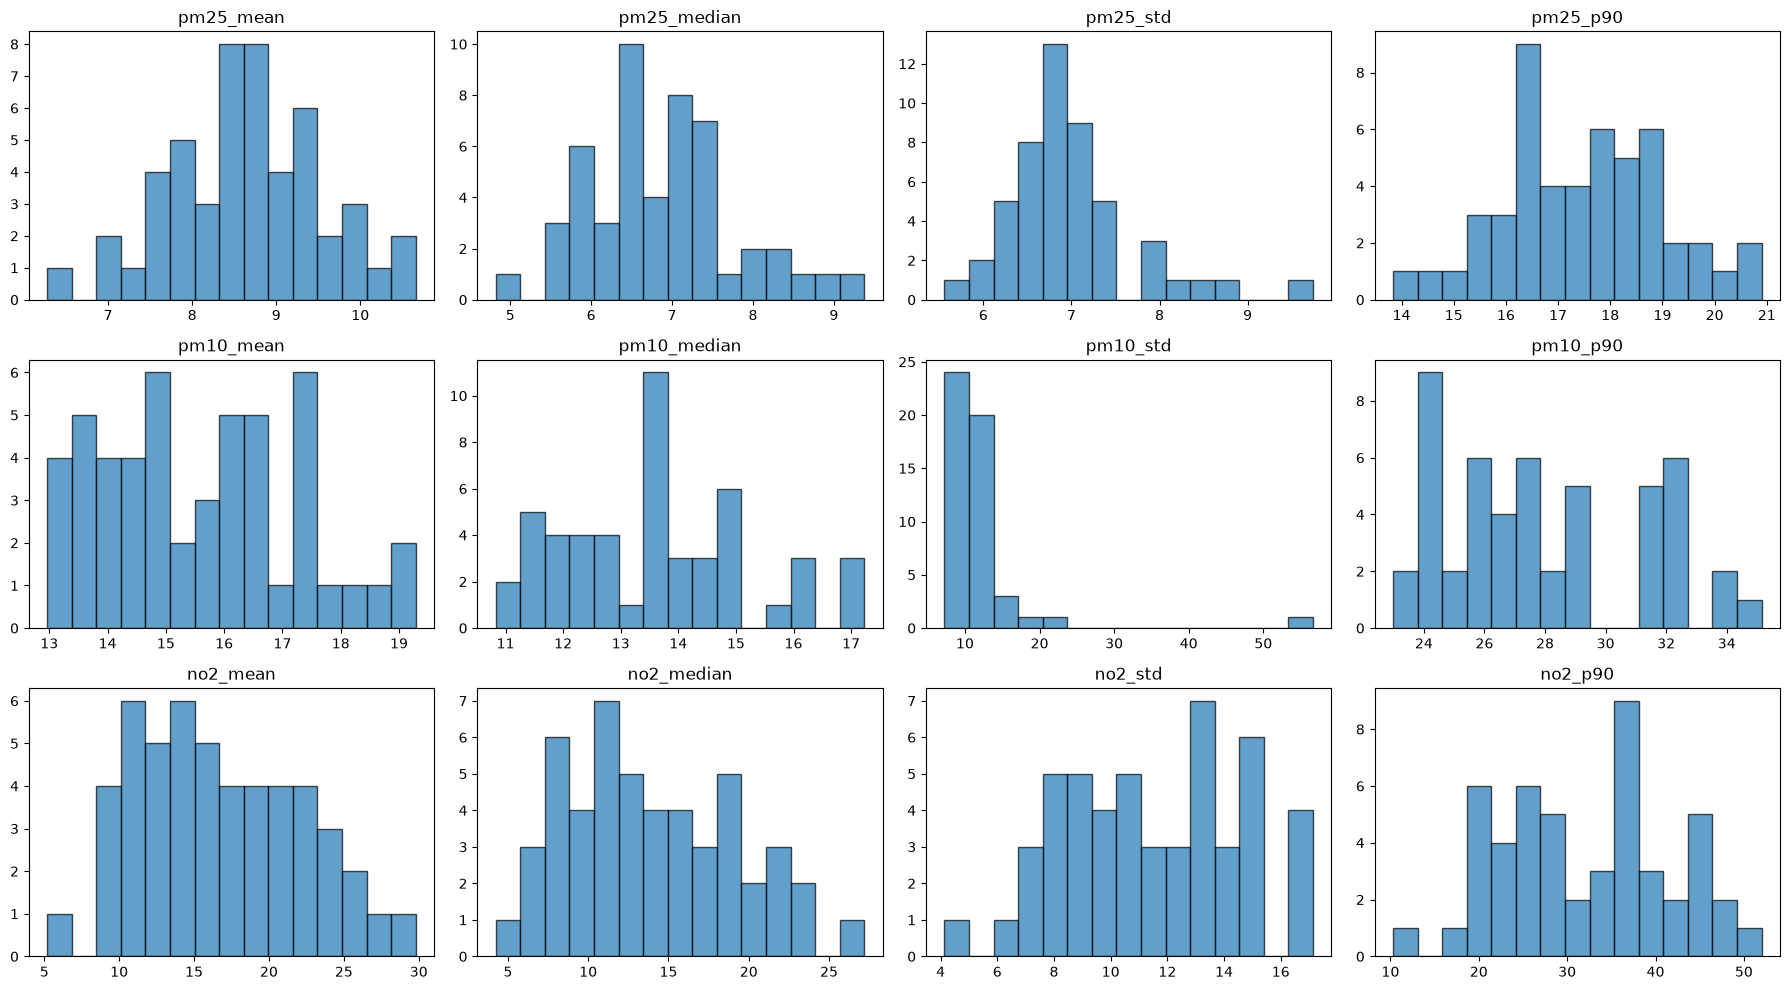

In [33]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(CLUSTERING_FEATURES):
    axes[i].hist(station_features_clustering[col], bins=15, edgecolor="black", alpha=0.7)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

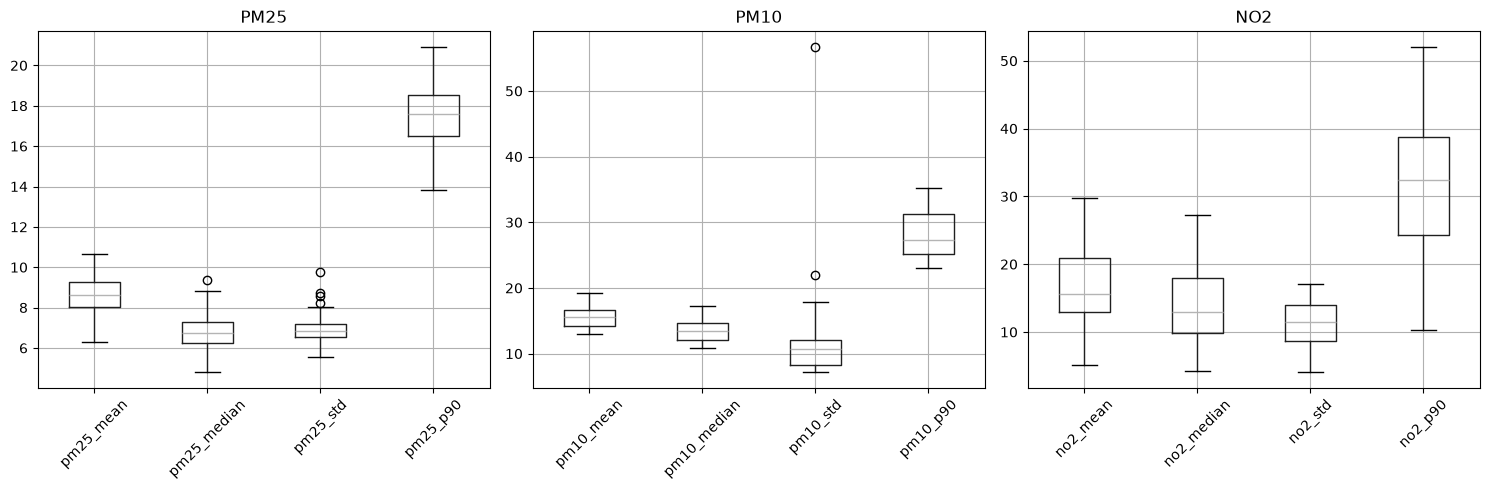

In [34]:
# boxplots to spot outlier stations directly
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, pollutant in zip(axes, ["pm25", "pm10", "no2"]):
    cols = [f"{pollutant}_mean", f"{pollutant}_median", f"{pollutant}_std", f"{pollutant}_p90"]
    station_features_clustering[cols].boxplot(ax=ax)
    ax.set_title(pollutant.upper())
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [35]:
station_features_clustering.sort_values("pm10_std", ascending=False).head(5)[["pm10_mean", "pm10_median", "pm10_std", "pm10_p90"]]

,pm10_mean,pm10_median,pm10_std,pm10_p90
meetlocatie_id,,,,
NL53016,16.641870,11.50,56.658666,24.80
NL01485,16.379735,13.80,22.048699,26.70
NL10449,19.285963,17.23,17.795476,33.87
NL10404,17.247471,14.67,15.177988,32.59
NL10937,17.256402,14.67,14.022842,32.59


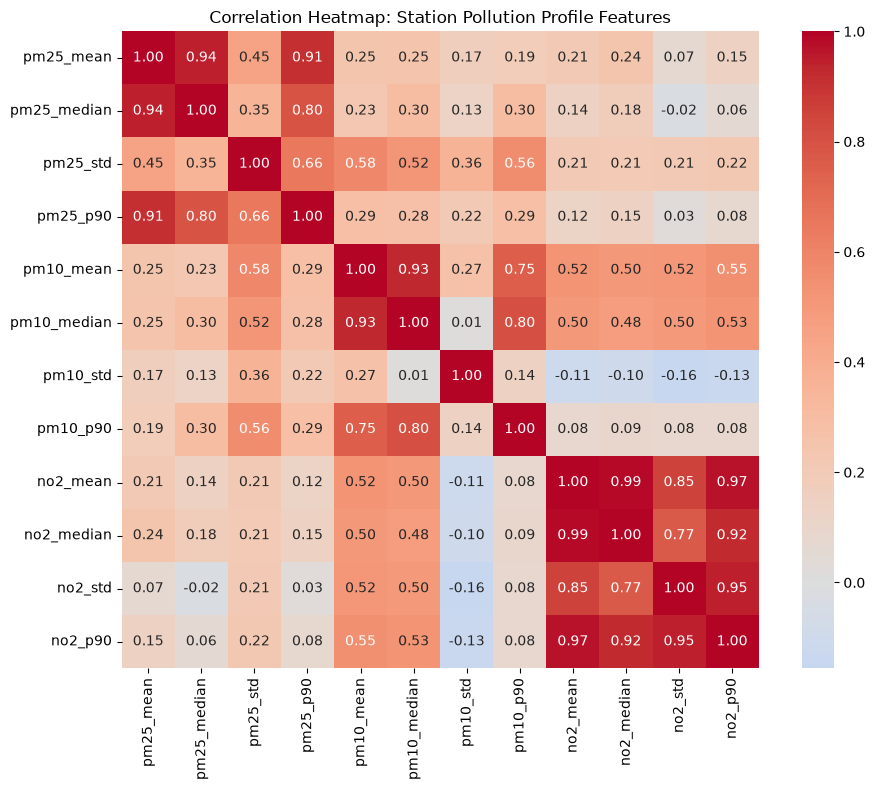

In [36]:
# correlation heatmap across all 12 features
plt.figure(figsize=(10, 8))
corr = station_features_clustering.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap: Station Pollution Profile Features")
plt.tight_layout()
plt.show()

In [37]:
# investigate NL53016's extreme PM10 readings
station_hourly = clean_pm10[clean_pm10["meetlocatie_id"] == "NL53016"].sort_values("begindatumtijd")

print(station_hourly["waarde"].describe())
print("\nTop 10 highest hourly readings:")
print(station_hourly.nlargest(10, "waarde")[["begindatumtijd", "waarde"]])

count    8579.000000
mean       16.641870
std        56.658666
min         0.600000
25%         7.700000
50%        11.500000
75%        17.300000
max      1018.400000
Name: waarde, dtype: float64

Top 10 highest hourly readings:
                  begindatumtijd  waarde
700401 2024-08-19 15:00:00+00:00  1018.4
700398 2024-08-19 12:00:00+00:00  1018.1
700400 2024-08-19 14:00:00+00:00  1018.1
700402 2024-08-19 16:00:00+00:00  1017.9
700399 2024-08-19 13:00:00+00:00  1017.8
700397 2024-08-19 11:00:00+00:00  1017.7
700396 2024-08-19 10:00:00+00:00  1017.6
700403 2024-08-19 17:00:00+00:00  1016.0
700411 2024-08-20 01:00:00+00:00  1014.3
700415 2024-08-20 05:00:00+00:00  1014.3


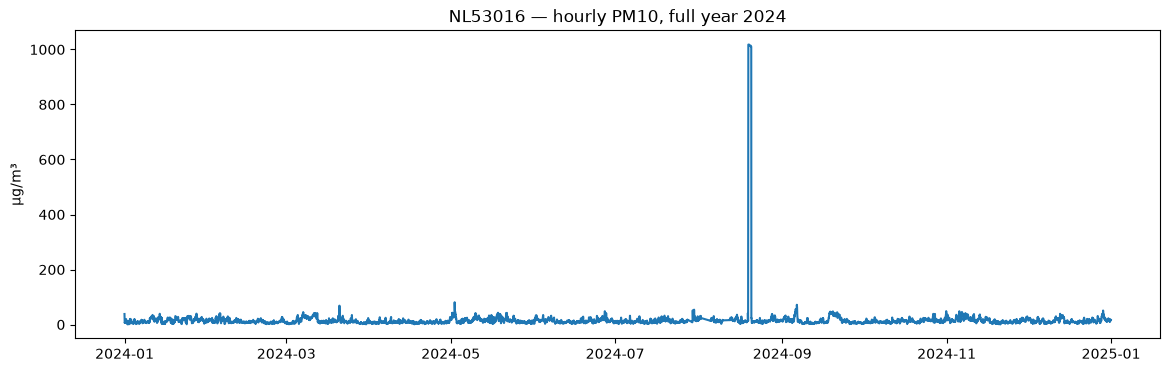

In [38]:
plt.figure(figsize=(14, 4))
plt.plot(station_hourly["begindatumtijd"], station_hourly["waarde"])
plt.title("NL53016 — hourly PM10, full year 2024")
plt.ylabel("µg/m³")
plt.show()

In [39]:
# drop highly redundant features
def find_redundant_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > threshold)]
    return to_drop

redundant = find_redundant_features(station_features_clustering, threshold=0.95)
print("Features flagged as redundant (r > 0.95 with an earlier feature):", redundant)

Features flagged as redundant (r > 0.95 with an earlier feature): ['no2_median', 'no2_p90']


In [40]:
episode = station_hourly[station_hourly["waarde"] > 500].sort_values("begindatumtijd")
print(f"Number of hours with waarde > 500: {len(episode)}")
print(episode[["begindatumtijd", "waarde"]])

Number of hours with waarde > 500: 27
                  begindatumtijd  waarde
700396 2024-08-19 10:00:00+00:00  1017.6
700397 2024-08-19 11:00:00+00:00  1017.7
700398 2024-08-19 12:00:00+00:00  1018.1
700399 2024-08-19 13:00:00+00:00  1017.8
700400 2024-08-19 14:00:00+00:00  1018.1
700401 2024-08-19 15:00:00+00:00  1018.4
700402 2024-08-19 16:00:00+00:00  1017.9
700403 2024-08-19 17:00:00+00:00  1016.0
700404 2024-08-19 18:00:00+00:00  1014.0
700405 2024-08-19 19:00:00+00:00  1014.0
700406 2024-08-19 20:00:00+00:00  1014.0
700407 2024-08-19 21:00:00+00:00  1014.1
700408 2024-08-19 22:00:00+00:00  1013.8
700409 2024-08-19 23:00:00+00:00  1013.7
700410 2024-08-20 00:00:00+00:00  1013.8
700411 2024-08-20 01:00:00+00:00  1014.3
700412 2024-08-20 02:00:00+00:00  1013.7
700413 2024-08-20 03:00:00+00:00  1013.7
700414 2024-08-20 04:00:00+00:00  1014.2
700415 2024-08-20 05:00:00+00:00  1014.3
700416 2024-08-20 06:00:00+00:00  1014.1
700417 2024-08-20 07:00:00+00:00  1012.5
700418 2024-08-20 0

In [41]:
# Domain-based cutoff: hourly PM10 above 500 µg/m³ sustained for many consecutive hours
# is not plausible ambient air quality — treat as sensor malfunction, not a real reading.
SENSOR_FAULT_THRESHOLD = 500

n_faulty = (clean_pm10["waarde"] > SENSOR_FAULT_THRESHOLD).sum()
print(f"Hourly readings above {SENSOR_FAULT_THRESHOLD} µg/m³ across all PM10 stations: {n_faulty}")

clean_pm10_filtered = clean_pm10[clean_pm10["waarde"] <= SENSOR_FAULT_THRESHOLD].copy()

# Recompute PM10 features with the faulty readings excluded
feat_pm10 = engineer_station_features(clean_pm10_filtered, "pm10")
print(feat_pm10.loc["NL53016"])

Hourly readings above 500 µg/m³ across all PM10 stations: 35
pm10_mean        13.492247
pm10_median      11.500000
pm10_std          8.241486
pm10_p90         24.600000
pm10_n_obs     8552.000000
Name: NL53016, dtype: float64


In [43]:
# rebuild the primary feature table
station_features_primary = (
    feat_pm25
    .join(feat_pm10, how="inner")
    .join(feat_no2, how="inner")
)
station_features_primary = station_features_primary.loc[
    station_features_primary.index.intersection(qualifying_stations.index)
]
station_features_clustering = station_features_primary[CLUSTERING_FEATURES].copy()

print(station_features_clustering["pm10_std"].describe())
print("\nSkew after fix:", station_features_clustering["pm10_std"].skew())

count    50.000000
mean     10.148268
std       2.052933
min       7.236040
25%       8.237329
50%       9.752228
75%      11.961880
max      14.022842
Name: pm10_std, dtype: float64

Skew after fix: 0.37987752827627813


In [44]:
CLUSTERING_FEATURES = [
    "pm25_mean", "pm25_median", "pm25_std", "pm25_p90",
    "pm10_mean", "pm10_median", "pm10_std", "pm10_p90",
    "no2_mean", "no2_std",  # no2_median and no2_p90 dropped: r > 0.95 with no2_mean/no2_std
]
station_features_clustering = station_features_primary[CLUSTERING_FEATURES].copy()
print(station_features_clustering.shape)

(50, 10)


In [45]:
faulty_readings = clean_pm10[clean_pm10["waarde"] > SENSOR_FAULT_THRESHOLD]
print(faulty_readings.groupby("meetlocatie_id").size())

meetlocatie_id
NL01485     2
NL10404     1
NL10445     1
NL10446     1
NL10449     1
NL10450     1
NL49561     1
NL53016    27
dtype: int64


### Sensor-fault handling (distinct from the negative-value noise decision)

Station **NL53016** showed 27 consecutive hourly PM10 readings between 1,009–1,018 µg/m³ on
2024-08-19/20  over 50× the station's typical range, sustained for more than a full day with
almost no variation (a real pollution spike would still fluctuate hour to hour). This pattern is
consistent with a stuck or saturated sensor rather than a genuine air-quality event, and it was
inflating `pm10_std` for this station to more than double the next-highest station (56.7 vs.
22.0), producing severe right-skew (skew = 5.46) across the whole feature.

**Decision:** hourly PM10 readings above 500 µg/m³ (a domain-implausible sustained level) were
excluded from the annual feature calculation, network-wide, rather than only for NL53016 
applying the same rule consistently regardless of station. This differs from the earlier
negative-value decision: those were small-magnitude readings near zero, consistent with normal
instrument noise and safely clippable; this is a large-magnitude, sustained anomaly inconsistent
with any plausible ambient air-quality reading, better handled by exclusion. After exclusion,
`pm10_std` skew dropped from 5.46 to 0.38 and NL53016's profile is now in line with comparable
stations.

### Redundant feature removal

Applying a correlation threshold of r > 0.95 (per standard feature-selection practice) identified
`no2_median` and `no2_p90` as redundant with `no2_mean` and `no2_std` respectively (r = 0.99 and
0.95). Both were dropped from the clustering feature set to avoid double-weighting NO2's central
tendency in the distance metric. PM2.5 and PM10 mean/median pairs were close (r = 0.93–0.94) but
below the threshold and were retained, since their std/p90 companions still carry distinct signal.

**Final clustering feature set (10 features):** pm25_mean, pm25_median, pm25_std, pm25_p90,
pm10_mean, pm10_median, pm10_std, pm10_p90, no2_mean, no2_std.

In [46]:
print(station_features_clustering.skew().sort_values(ascending=False))

pm25_std       1.481659
pm25_median    0.558164
pm10_median    0.477741
pm10_p90       0.435053
pm10_mean      0.425864
pm10_std       0.379878
no2_mean       0.259661
pm25_p90       0.092060
pm25_mean     -0.050881
no2_std       -0.082743
dtype: float64


In [47]:
SKEW_THRESHOLD = 1.0  # commonly used cutoff for "needs transformation"

skewness = station_features_clustering.skew()
skewed_features = skewness[skewness.abs() > SKEW_THRESHOLD].index.tolist()
print("Features to log1p-transform:", skewed_features)

station_features_transformed = station_features_clustering.copy()
for col in skewed_features:
    station_features_transformed[col] = np.log1p(station_features_transformed[col])

print("\nSkew after transform:")
print(station_features_transformed[skewed_features].skew())

Features to log1p-transform: ['pm25_std']

Skew after transform:
pm25_std    1.085921
dtype: float64


In [48]:
scaler = StandardScaler()
station_features_scaled = pd.DataFrame(
    scaler.fit_transform(station_features_transformed),
    index=station_features_transformed.index,
    columns=station_features_transformed.columns
)

print(station_features_scaled.shape)
station_features_scaled.describe().round(2)

(50, 10)


,pm25_mean,pm25_median,pm25_std,pm25_p90,pm10_mean,pm10_median,pm10_std,pm10_p90,no2_mean,no2_std
count,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00
std,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01,1.01
min,-2.57,-2.27,-2.18,-2.35,-1.52,-1.69,-1.43,-1.49,-2.13,-2.38
25%,-0.67,-0.65,-0.60,-0.65,-0.85,-0.90,-0.94,-0.88,-0.71,-0.90
50%,0.00,-0.11,-0.16,0.04,-0.13,-0.10,-0.19,-0.17,-0.22,-0.00
75%,0.67,0.51,0.36,0.67,0.63,0.65,0.89,1.03,0.77,0.85
max,2.21,2.83,3.46,2.17,2.23,2.28,1.91,2.19,2.40,1.86


## Preprocessing for Clustering

**Skewness check:** most features showed mild-to-moderate skew (|skew| < 1.5), typical for
environmental concentration data. Only `pm25_std` exceeded the |skew| > 1.0 threshold used to flag
transformation candidates (1.48).

**Log transform:** `np.log1p` was applied to `pm25_std` only. This reduced its skew to 1.09 
a partial improvement; the remaining mild skew was left as-is rather than applying further
transformation, which risks distorting the feature more than the residual skew justifies.

**Scaling:** `StandardScaler` (zero mean, unit variance) was applied to all 10 features after the
log transform. This step is essential before any distance-based clustering: although all features
share the same physical unit (µg/m³), they differ substantially in scale and spread (e.g. NO2
values run roughly 2–3× higher than PM2.5), and K-Means' Euclidean distance would otherwise let
higher-magnitude features like `no2_mean`/`no2_std` dominate cluster formation over PM2.5's
comparatively smaller values  even though both are equally relevant to the pollution profile.

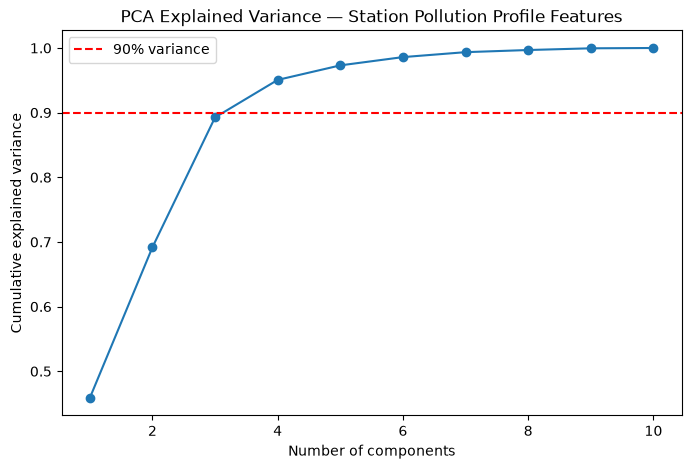

PC1: 45.9% (cumulative 45.9%)
PC2: 23.3% (cumulative 69.2%)
PC3: 20.1% (cumulative 89.3%)
PC4: 5.8% (cumulative 95.1%)
PC5: 2.2% (cumulative 97.3%)
PC6: 1.3% (cumulative 98.6%)
PC7: 0.8% (cumulative 99.4%)
PC8: 0.3% (cumulative 99.7%)
PC9: 0.3% (cumulative 100.0%)
PC10: 0.0% (cumulative 100.0%)


In [49]:
pca_check = PCA(random_state=RANDOM_STATE)
pca_check.fit(station_features_scaled)

explained = pca_check.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), cumulative, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance — Station Pollution Profile Features")
plt.legend()
plt.show()

for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i}: {e:.1%} (cumulative {c:.1%})")

## Dimensionality Reduction (Optional)

PCA was applied to the 10 scaled clustering features to check how much redundancy remains after
feature selection. The first 3 principal components explain 89.3% of total variance (PC1: 45.9%,
PC2: 23.3%, PC3: 20.1%), with a clear elbow after PC3  each further component adds under 6%.

This is expected: even after removing features with r > 0.95, each pollutant's mean/median/std/p90
group still shares real structure (e.g. `pm25_mean` and `pm25_median` correlated at 0.94, just
under the removal threshold). It confirms the underlying signal in this feature set is genuinely
lower-dimensional than 10 raw features suggest.

**Use here:** PCA is used for visualization and structure-checking only, not as the basis for
clustering  clustering will be performed on the full scaled 10-feature space, so pollutant 
specific nuance (e.g. distinguishing a "high-mean, low-variance" profile from a "moderate-mean,
high-variance/spiky" profile) is preserved rather than collapsed. A 2D PCA projection will be used
later, after clustering, purely to visualize the resulting cluster separation.

In [52]:
from sklearn.neighbors import NearestNeighbors

def hopkins_statistic(X, sample_ratio=0.1, random_state=RANDOM_STATE):
    """
    Hopkins statistic for cluster tendency.
    Compares nearest-neighbor distances of real sample points against
    distances from uniformly random points in the same feature space.
    Values well below 0.5 indicate clusterable structure;
    values near 0.5 indicate the data is close to uniformly random.
    """
    rng = np.random.default_rng(random_state)
    n, d = X.shape
    m = max(1, int(sample_ratio * n))

    # Sample m real points (without replacement)
    real_sample_idx = rng.choice(n, m, replace=False)
    X_real_sample = X[real_sample_idx]

    # Generate m uniform random points within the feature space's bounding box
    mins, maxs = X.min(axis=0), X.max(axis=0)
    X_uniform = rng.uniform(mins, maxs, size=(m, d))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # For real points: distance to nearest OTHER real point (skip distance-0 self-match)
    u_distances, _ = nbrs.kneighbors(X_real_sample)
    u_distances = u_distances[:, 1]

    # For uniform random points: distance to nearest real point
    w_distances, _ = nbrs.kneighbors(X_uniform)
    w_distances = w_distances[:, 0]

    H = w_distances.sum() / (w_distances.sum() + u_distances.sum())
    return H

X = station_features_scaled.values
H = hopkins_statistic(X)
print(f"Hopkins statistic: {H:.3f}")
print("(closer to 0 = strong cluster tendency; ~0.5 = random/uniform; closer to 1 = regularly spaced)")

Hopkins statistic: 0.627
(closer to 0 = strong cluster tendency; ~0.5 = random/uniform; closer to 1 = regularly spaced)


In [51]:
scores = [hopkins_statistic(X, random_state=seed) for seed in range(10)]
print("Hopkins statistic across 10 random seeds:")
print(f"Mean: {np.mean(scores):.3f}, Std: {np.std(scores):.3f}")
print(scores)

Hopkins statistic across 10 random seeds:
Mean: 0.684, Std: 0.036
[np.float64(0.6999990467888806), np.float64(0.6319647131775102), np.float64(0.6605108561903311), np.float64(0.7045552936477814), np.float64(0.7288721723434491), np.float64(0.6731205902992914), np.float64(0.6697017962099325), np.float64(0.7025123259733559), np.float64(0.6252887294042921), np.float64(0.7403699547334679)]


In [53]:
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca_3d.fit_transform(station_features_scaled)

scores_pca = [hopkins_statistic(X_pca3, random_state=seed) for seed in range(10)]
print("Hopkins statistic on 3-component PCA space:")
print(f"Mean: {np.mean(scores_pca):.3f}, Std: {np.std(scores_pca):.3f}")
print(scores_pca)

Hopkins statistic on 3-component PCA space:
Mean: 0.570, Std: 0.063
[np.float64(0.606411827202247), np.float64(0.4639152201832591), np.float64(0.5347443040168163), np.float64(0.6094412627366509), np.float64(0.5966294168414146), np.float64(0.5838062134777702), np.float64(0.585650515668649), np.float64(0.5591890837629734), np.float64(0.4752119300665173), np.float64(0.6866751612455203)]


## Cluster Tendency Check (Hopkins Statistic)

Before fitting K-Means, the Hopkins statistic was computed to assess whether the station
pollution-profile data contains genuine cluster structure or is closer to uniformly/randomly
distributed.

- **Full 10-feature scaled space:** mean 0.684 (std 0.036) across 10 random seeds.
- **3-component PCA-reduced space** (89.3% of variance retained): mean 0.570 (std 0.063), with
  individual seeds ranging as low as 0.464.

Both results sit above the 0.5 threshold the lesson material associates with clusterable
structure, though the PCA-space result is notably closer to that threshold  some of the apparent
randomness in the full feature space is consistent with the curse of dimensionality (nearest-
neighbor distances becoming less meaningful as dimensions grow relative to the 50-station sample),
rather than reflecting the data's true structure. Even so, neither result indicates strong,
well-separated cluster structure.

**Implication:** this is treated as an honest signal to set expectations, not a reason to abandon
clustering. K-Means can still surface interpretable, useful groupings on data with moderate rather
than sharp separation  a realistic outcome for continuous environmental measurements, which
rarely fall into hard natural categories. Given this result, cluster count selection (next section)
will weight interpretability and stability at least as heavily as silhouette/Davies-Bouldin scores,
and a smaller k (e.g. 2–4) should be considered a legitimate, honest outcome rather than something
to avoid in favor of a higher, better-sounding number. This will be revisited explicitly in the
Evaluation and Limitations section.

## Clustering Algorithm Options

| Aspect | K-Means | DBSCAN | Hierarchical (Agglomerative) |
|---|---|---|---|
| Core assumption | Spherical, similarly-sized, similarly-dense clusters | Dense regions separated by sparse gaps, uniform density within a cluster | Meaningful nested structure exists in the data |
| Key parameters | k (number of clusters) | eps (neighborhood radius), min_samples | linkage method (ward, complete, average), number of clusters to cut at |
| Parameter sensitivity | Moderate ;wrong k gives poor but still-computed results | High ;small eps/min_samples changes can swing cluster count drastically | Moderate ; linkage choice changes cluster shape/balance |
| Handles outliers | Poorly ; outliers pull centroids | Well ; explicit noise category | Poorly ; outliers distort the whole merge hierarchy |
| Strengths for this data | Efficient, deterministic, interpretable centroids as "typical profiles" | Automatic cluster count, explicit noise detection | No need to pre-specify k; dendrogram shows nested similarity |
| Weaknesses for this data | Requires choosing k; assumes fairly even cluster sizes | Struggles at small n (50) and with weak density contrast (confirmed by our Hopkins statistic ~0.57-0.68); parameter-sensitive | Computationally fine at n=50, but Dutch monitoring stations have no known natural nested hierarchy ; risk of imposing artificial structure |

## Algorithm Choice for This Dataset

**Dataset profile:** 50 stations × 10 scaled features (PM2.5/PM10/NO2 mean/median/std/p90). This
falls in the "very small" sample-size category, where K-Means and hierarchical clustering are
both fully feasible, but DBSCAN's density estimates become unreliable.

**Cluster shape expectations:** no strong reason to expect irregular or elongated cluster shapes
in annual pollutant summary statistics  these are smooth aggregate measures, not raw spatial
plume data. Combined with the earlier Hopkins statistic (0.57-0.68, weak-to-moderate cluster
tendency rather than sharply separated groups), we expect moderately overlapping, roughly
convex groupings rather than DBSCAN's target case of dense islands separated by empty space.

**Noise/outliers:** the sensor-fault episode was already removed during cleaning (Milestone 2).
No further outlier-heavy structure is expected, reducing one of DBSCAN's key advantages.

**Feature types and scaling:** all 10 features are continuous and standardized (StandardScaler),
which suits distance-based methods generally  no categorical-encoding or mixed-metric concerns.

**Decision:** K-Means is the primary algorithm  its assumptions (roughly spherical, similarly
sized groups) are a reasonable match for smooth station-level pollutant summaries, it gives
directly interpretable centroids ("typical profiles" per cluster), and it fits this project's
goal of assigning every station to one clear profile group. Hierarchical clustering (Ward linkage)
is used as a secondary validation method  not because Dutch stations are expected to have a
true nested hierarchy, but because comparing its flat-cut clusters against K-Means' assignments is
a useful robustness check (per the project's original evaluation plan). DBSCAN is tested for
completeness and to honestly report whether it can find structure at all, but is not expected to
be the primary method given the small sample size and weak density contrast already observed.

In [54]:
# K-Means: k=2 through 8, inertia + silhouette + Davies-Bouldin:
X = station_features_scaled.values

k_values = range(2, 9)
inertias = []
silhouette_scores = []
db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

    print(f"k={k}: inertia={kmeans.inertia_:.1f}, silhouette={silhouette_scores[-1]:.3f}, "
          f"davies-bouldin={db_scores[-1]:.3f}")

k=2: inertia=347.1, silhouette=0.274, davies-bouldin=1.425
k=3: inertia=281.4, silhouette=0.244, davies-bouldin=1.283
k=4: inertia=224.1, silhouette=0.275, davies-bouldin=1.119
k=5: inertia=182.8, silhouette=0.273, davies-bouldin=1.132
k=6: inertia=154.9, silhouette=0.272, davies-bouldin=1.095
k=7: inertia=136.9, silhouette=0.287, davies-bouldin=1.091
k=8: inertia=116.5, silhouette=0.301, davies-bouldin=1.025


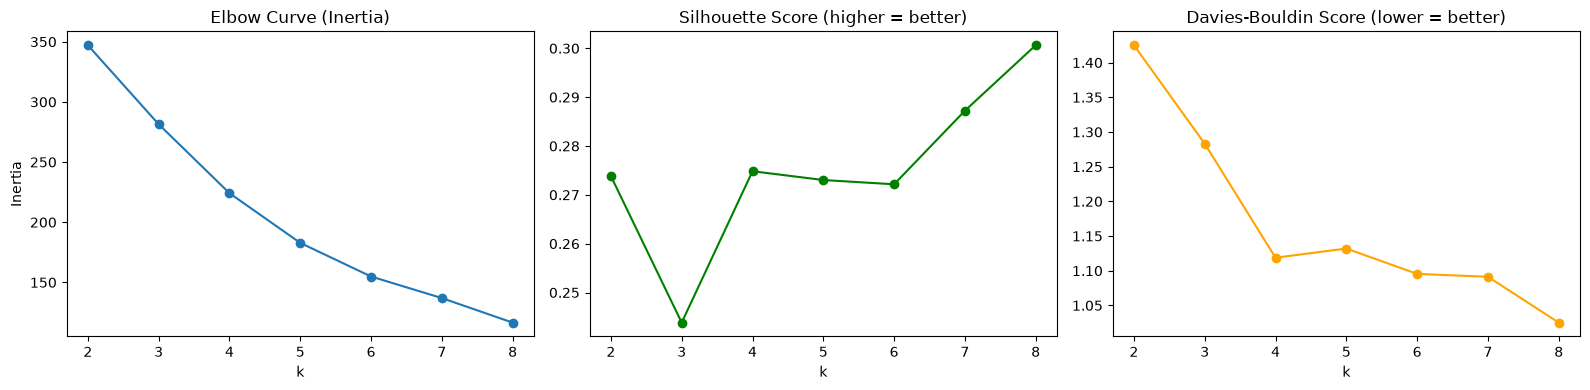

In [55]:
# plot elbow, silhouette, and Davies-Bouldin curves:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_title("Elbow Curve (Inertia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_values), silhouette_scores, marker="o", color="green")
axes[1].set_title("Silhouette Score (higher = better)")
axes[1].set_xlabel("k")

axes[2].plot(list(k_values), db_scores, marker="o", color="orange")
axes[2].set_title("Davies-Bouldin Score (lower = better)")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()

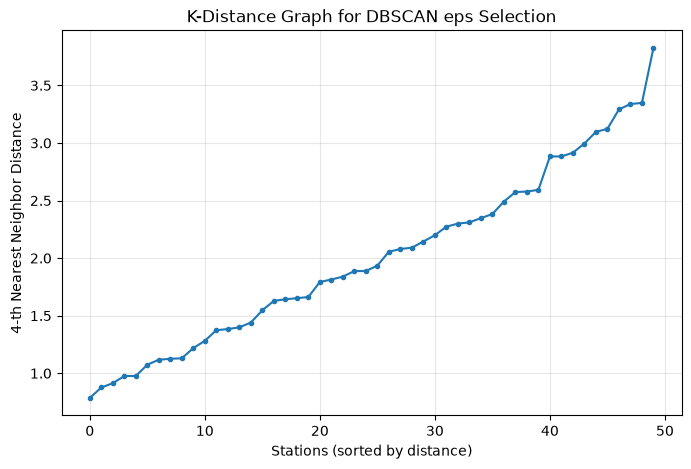

[0.78528586 0.87658885 0.91340406 0.97643376 0.97643376 1.07437441
 1.1176385  1.12577608 1.13007137 1.21865998 1.28153278 1.37408901
 1.38394513 1.39869589 1.44058856 1.5467428  1.62877409 1.64245195
 1.65177766 1.66224734 1.79258954 1.81427538 1.83934821 1.88768089
 1.88768089 1.93513039 2.05548205 2.07917831 2.09061153 2.14411249
 2.19890574 2.27323502 2.29977749 2.31022683 2.34735142 2.38281966
 2.49119445 2.57351503 2.57825521 2.59279807 2.88301286 2.88301286
 2.91580542 2.99499152 3.09646485 3.12256758 3.29097378 3.33831408
 3.34778653 3.82478512]


In [56]:
# DBSCAN: k-distance graph to inform eps, per this lesson's method:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES_CANDIDATE = 4  # roughly 2 x n_features_effective is a common rule of thumb; small n here

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_CANDIDATE).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, MIN_SAMPLES_CANDIDATE - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances, marker="o", markersize=3)
plt.xlabel("Stations (sorted by distance)")
plt.ylabel(f"{MIN_SAMPLES_CANDIDATE}-th Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN eps Selection")
plt.grid(True, alpha=0.3)
plt.show()

print(k_distances)

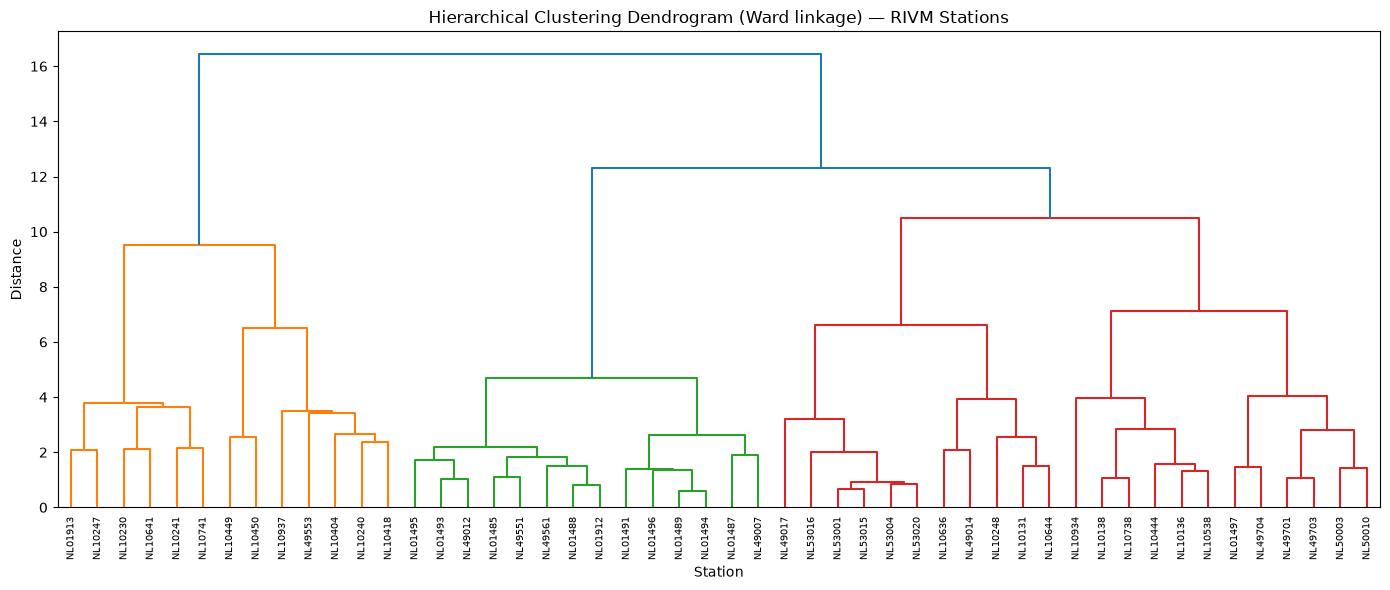

In [58]:
# Hierarchical: dendrogram + linkage comparison at a fixed k for reference:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

linkage_matrix = linkage(X, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, labels=station_features_scaled.index.tolist(),
           leaf_rotation=90, leaf_font_size=7)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage) — RIVM Stations")
plt.xlabel("Station")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [59]:
for method in ["ward", "complete", "average"]:
    lm = linkage(X, method=method)
    labels_4 = fcluster(lm, t=4, criterion="maxclust") - 1
    sil = silhouette_score(X, labels_4)
    print(f"{method}: silhouette at k=4 → {sil:.3f}")

ward: silhouette at k=4 → 0.240
complete: silhouette at k=4 → 0.157
average: silhouette at k=4 → 0.264


In [60]:
# K-Means cluster size balance across candidate k values:
for k in [3, 4, 5, 7, 8]:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X)
    sizes = pd.Series(labels).value_counts().sort_index()
    print(f"k={k}: cluster sizes = {sizes.tolist()}")

k=3: cluster sizes = [16, 24, 10]
k=4: cluster sizes = [18, 12, 9, 11]
k=5: cluster sizes = [7, 9, 11, 8, 15]
k=7: cluster sizes = [5, 6, 7, 7, 6, 14, 5]
k=8: cluster sizes = [5, 11, 6, 10, 2, 5, 6, 5]


In [62]:
from sklearn.cluster import DBSCAN

In [63]:
# DBSCAN at a few eps values around the mild inflection:
for eps in [1.5, 2.0, 2.3, 2.6, 3.0]:
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES_CANDIDATE)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels)*100:.0f}%)")

eps=1.5: 2 clusters, 32 noise points (64%)
eps=2.0: 3 clusters, 18 noise points (36%)
eps=2.3: 2 clusters, 9 noise points (18%)
eps=2.6: 1 clusters, 4 noise points (8%)
eps=3.0: 1 clusters, 1 noise points (2%)


## Results & Parameter Choices

### K-Means
Tested k = 2 through 8. Inertia declined smoothly with no sharp elbow (expected, given the
moderate cluster tendency found earlier via the Hopkins statistic). Silhouette and Davies-Bouldin
scores independently agreed on a **local optimum at k=4** (silhouette 0.275, Davies-Bouldin 1.119
 both better than k=3 and k=5-6). k=7 and k=8 scored marginally better on both metrics, but
cluster-size inspection showed why this is misleading: k=8 produced a cluster of just **2**
stations, and k=7 produced several thin clusters of 5-6  a classic small-sample overfitting
pattern, where extra clusters chase a couple of atypical stations rather than finding genuine
structure. **k=4** gives the most balanced split (18, 12, 9, 11 stations) alongside the strongest
combined silhouette/Davies-Bouldin result, and was selected as the primary K-Means solution.

### DBSCAN
The k-distance graph (min_samples=4) showed **no clear knee**  distances rose smoothly and
gradually from ~0.8 to ~3.8 across all 50 stations, unlike the sharp knee a density-separated
dataset typically shows. A parameter sweep confirmed the resulting instability: tight eps values
(1.5-2.0) flagged 36-64% of stations as noise; looser eps values (2.6-3.0) collapsed almost all
stations into a single cluster (97-98% of points, 1-2 noise points). No eps value in a reasonable
range produced a balanced clustering with both a sensible cluster count and a sensible noise rate.
**DBSCAN was not able to find usable structure in this dataset**  consistent with the Hopkins
statistic result and the algorithm's known sensitivity to weak density contrast, which was
anticipated in the Algorithm Choice section above. This is reported as a genuine finding, not
treated as a failed experiment: it reinforces that station pollution profiles form a continuum
rather than dense, well-separated islands.

### Hierarchical (Agglomerative)
The Ward-linkage dendrogram shows an interpretable top-level split into **3 major branches**
merging around distance 16.4, giving a genuine, non-arbitrary structural signal. At a 4-cluster
cut for direct comparison with K-Means, Ward linkage scored silhouette 0.240 (below K-Means'
0.275  expected, since Ward optimizes variance reduction along a tree rather than directly
optimizing cluster compactness). Average linkage scored slightly higher (0.264) but complete
linkage was notably worse (0.157), confirming Ward as the more appropriate linkage for this data.

### Carried forward
**K-Means with k=4** is the primary clustering solution carried forward for detailed evaluation
and interpretation. **Hierarchical clustering (Ward linkage)** is retained as a secondary
validation check  despite its lower raw silhouette score, its independent 3-4 branch structure
broadly agrees with K-Means' 4-cluster split, which is itself useful evidence of robustness.
**DBSCAN is not carried forward** as a primary method, given its inability to produce a stable,
interpretable clustering at any tested parameter setting  a limitation of the algorithm for this
dataset's sample size and density profile, not a data quality issue.

### Risk of biased or misleading segmentation
A meaningful risk with only 50 stations and moderate cluster separation is that any given k
partly reflects which specific stations happen to be in the sample, not a stable underlying
pollution typology. Small clusters (as small as 9-12 stations at k=4) could shift noticeably if a
few borderline stations were added, removed, or measured over a different year. This will be
tested directly in the next milestone via stability checks (e.g. re-running with different random
seeds, bootstrap resampling) before treating cluster assignments as a firm basis for policy
recommendations.

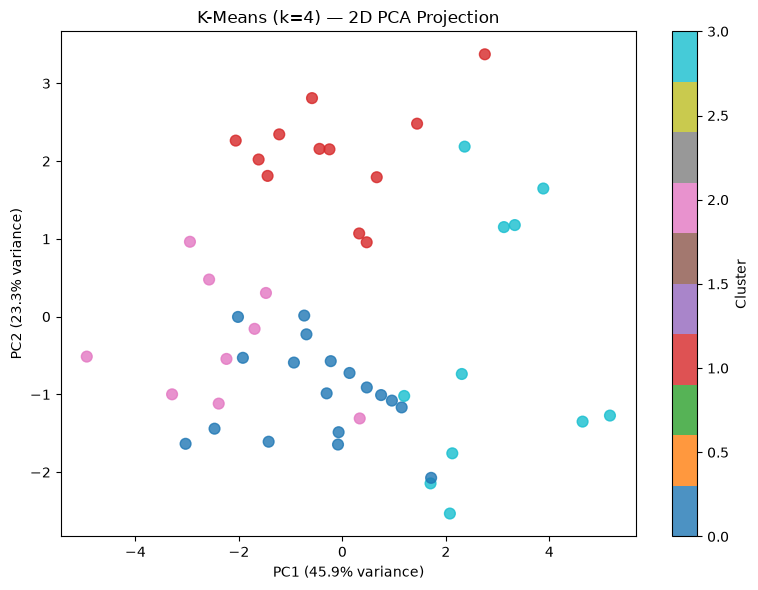

2D PCA captures 69.2% of total variance (a partial view  full clustering used all 10 features)


In [69]:
# visualize the chosen K-Means solution (k=4) via PCA 2D projection
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2d.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=kmeans_labels, cmap="tab10", s=60, alpha=0.8)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
plt.title(f"K-Means (k={final_k}) — 2D PCA Projection")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

print(f"2D PCA captures {pca_2d.explained_variance_ratio_.sum():.1%} of total variance "
      f"(a partial view  full clustering used all 10 features)")

### K-Means (k=4) Visual Check

The 2D PCA projection (69.2% of total variance) shows one clearly separated cluster (upper region,
high PC2) and three other clusters with visible overlap, particularly between two clusters in the
middle-left region. This is consistent with the Hopkins statistic result from Milestone 2 (weak-
to-moderate cluster tendency)  this dataset does not have four cleanly isolated groups. The
overlap seen here is expected to be partly an artifact of viewing only 2 of 10 dimensions (69.2%,
not 100%, of variance), but the general pattern  one clearly distinct profile plus three related,
overlapping profiles  is a reasonable, honest summary of what K-Means found. Full interpretation
of what distinguishes each cluster (which pollutant(s) drive the separation) is deferred to the
Cluster Interpretation section, where unscaled feature means per cluster will be examined directly.

In [70]:
# bootstrap stability test for the k=4 K-Means solution:
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score

def kmeans_bootstrap_stability(X, k, n_trials=20, random_state=RANDOM_STATE):
    """
    Fit K-Means on bootstrap resamples of X, then compare each resample's
    labels back against the labels the SAME model would assign to the
    full original X (rather than comparing resamples to each other,
    which breaks when resample indices differ in composition).
    """
    reference_model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    reference_labels = reference_model.fit_predict(X)

    ari_scores = []
    for trial in range(n_trials):
        idx = resample(np.arange(len(X)), random_state=trial)
        X_boot = X[idx]

        boot_model = KMeans(n_clusters=k, random_state=trial, n_init=10)
        boot_model.fit(X_boot)

        # Predict cluster labels for the ORIGINAL data using the bootstrap-fitted centroids
        predicted_on_full = boot_model.predict(X)
        ari = adjusted_rand_score(reference_labels, predicted_on_full)
        ari_scores.append(ari)

    return np.array(ari_scores)

ari_scores = kmeans_bootstrap_stability(X, k=4, n_trials=20)
print(f"Mean ARI: {ari_scores.mean():.3f}, Std: {ari_scores.std():.3f}")
print(f"Min: {ari_scores.min():.3f}, Max: {ari_scores.max():.3f}")

Mean ARI: 0.431, Std: 0.164
Min: 0.255, Max: 0.859


### Cluster Stability Check (Bootstrap ARI)

To test whether the k=4 K-Means solution reflects genuine, robust structure or is sensitive to
which specific stations are in the 50-station sample, the model was refit on 20 bootstrap
resamples and each resample's predicted labels on the full dataset were compared against the
original solution using the Adjusted Rand Index (ARI).

**Result: mean ARI = 0.431 (std 0.164, range 0.255-0.859)**  below the 0.6 threshold typically
used as a "moderate stability" cutoff, indicating **low stability**. Some bootstrap runs agreed
closely with the original solution (ARI up to 0.86), but others diverged substantially (as low as
0.26), meaning cluster boundaries  particularly for stations near the edges of a cluster  shift
meaningfully depending on which stations happen to be resampled.

This is consistent with, and adds concrete evidence to, two earlier findings: the moderate Hopkins
statistic (0.57-0.68) and the visible overlap between clusters in the 2D PCA plot. Together, these
results point to the same conclusion: **the k=4 clustering captures a real but soft pattern, not a
set of firmly separated station types.** This will be treated as a headline limitation in the
Evaluation and Limitations section  cluster assignments should be read as indicative groupings
useful for prioritization discussions, not as a definitive, stable typology that individual
stations are permanently locked into.

### Note on the Practice Activity Workflow

The six-step experiment workflow (data preparation, algorithm selection, parameter optimization,
evaluation and comparison, interpretation, documentation) was followed throughout this milestone,
integrated into the sections above rather than run as a separate generic pass: preprocessing
choices were made and justified in Milestone 2; algorithm selection is documented in "Algorithm
Choice for This Dataset"; parameter optimization is the K-Means/DBSCAN/hierarchical experiments
above; evaluation combines silhouette, Davies-Bouldin, cluster balance, and bootstrap stability
(ARI); full interpretation (cluster profiling and stakeholder-friendly labeling) is the next step,
carried into cluster interpretation.

In [71]:
# Step 1: Permutation significance test:
def test_clustering_significance(data, labels, n_permutations=1000, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    observed_score = silhouette_score(data, labels)

    random_scores = np.empty(n_permutations)
    for i in range(n_permutations):
        random_labels = rng.permutation(labels)
        random_scores[i] = silhouette_score(data, random_labels)

    p_value = np.mean(random_scores >= observed_score)
    return observed_score, random_scores, p_value

kmeans_final_labels = kmeans_final.labels_  # from the k=4 model fit earlier
observed_score, random_scores, p_value = test_clustering_significance(X, kmeans_final_labels)

print(f"Observed silhouette score: {observed_score:.3f}")
print(f"Mean random-permutation silhouette: {random_scores.mean():.3f}")
print(f"P-value: {p_value:.4f}")

Observed silhouette score: 0.275
Mean random-permutation silhouette: -0.076
P-value: 0.0000


In [72]:
# Step 2: Bootstrap confidence interval on silhouette:
def bootstrap_silhouette_ci(data, k, n_bootstrap=100, random_state=RANDOM_STATE):
    scores = []
    for i in range(n_bootstrap):
        boot_data = resample(data, random_state=i)
        boot_labels = KMeans(n_clusters=k, random_state=i, n_init=10).fit_predict(boot_data)
        if len(set(boot_labels)) > 1:
            scores.append(silhouette_score(boot_data, boot_labels))
    scores = np.array(scores)
    ci_lower, ci_upper = np.percentile(scores, [2.5, 97.5])
    return scores, ci_lower, ci_upper

boot_scores, ci_lower, ci_upper = bootstrap_silhouette_ci(X, k=4)
print(f"Bootstrap mean silhouette: {boot_scores.mean():.3f}")
print(f"95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")
print(f"CI width: {ci_upper - ci_lower:.3f}")

Bootstrap mean silhouette: 0.350
95% CI: [0.296, 0.411]
CI width: 0.115


In [73]:
# Step 3: Clusterability was already assessed in Milestone 2 via the Hopkins statistic.
# Full 10-feature space: mean 0.684 (10 seeds). 3-component PCA space: mean 0.570.
# Both exceed this lesson's 0.6 "borderline-use-caution" floor but fall short of the 0.7
# "safe to proceed" bar - i.e. clustering was defensible to attempt, but always flagged
# here as moderate-confidence, not strong, evidence of true structure.

# Step 4: Professional interpretation, adapted for our actual context (n=50 -> small-dataset
# thresholds; environmental data -> standard thresholds, no domain adjustment applied)
def professional_interpretation(sil_score, p_value, ci_width, sample_size, domain="environmental", application="exploratory"):
    if sample_size < 500:
        excellent, good, fair = 0.5, 0.4, 0.25
    else:
        excellent, good, fair = 0.6, 0.5, 0.3

    if sil_score >= excellent:
        quality = "EXCELLENT"
    elif sil_score >= good:
        quality = "GOOD"
    elif sil_score >= fair:
        quality = "FAIR"
    else:
        quality = "POOR"

    print(f"Silhouette score: {sil_score:.3f} -> {quality} (small-sample thresholds: "
          f"excellent>={excellent}, good>={good}, fair>={fair})")
    print(f"P-value: {p_value:.4f} -> {'significant' if p_value < 0.05 else 'NOT significant'}")
    print(f"95% CI width: {ci_width:.3f} -> "
          f"{'narrow/reliable' if ci_width < 0.1 else 'moderate' if ci_width < 0.2 else 'wide/uncertain'}")
    return quality

quality = professional_interpretation(
    sil_score=observed_score,
    p_value=p_value,
    ci_width=(ci_upper - ci_lower),
    sample_size=50,
)

Silhouette score: 0.275 -> FAIR (small-sample thresholds: excellent>=0.5, good>=0.4, fair>=0.25)
P-value: 0.0000 -> significant
95% CI width: 0.115 -> moderate


## Statistical Validation

### 1. Significance Testing (Permutation Test)
The observed silhouette score (0.275) was compared against 1,000 random permutations of the same
cluster labels. Random permutations averaged **-0.076**  clusters formed by shuffled labels
show essentially no internal cohesion, as expected. The observed clustering beat every single
permutation (**p < 0.0001**), providing strong evidence that the k=4 solution captures real
structure in the pollutant-profile data rather than an artifact of the algorithm imposing groups
on random noise.

### 2. Bootstrap Confidence Interval
Refitting K-Means (k=4) on 100 bootstrap resamples gave a mean silhouette of 0.350, 95% CI
**[0.296, 0.411]**, a moderate width of 0.115. Note this CI is centered noticeably higher than the
0.275 observed on the original data bootstrap resampling (sampling with replacement) tends to
inflate apparent cluster compactness slightly, since repeated points sit at zero distance from
themselves. The CI should be read as "the clustering procedure reliably finds *some* structure of
this rough quality," not as a precise estimate of the original solution's exact score.

### 3. Clusterability Assessment (Hopkins, referenced from Milestone 2)
Hopkins statistic: 0.684 (full feature space), 0.570 (3-component PCA space)  above this lesson's
0.6 "use caution" floor but below the 0.7 "safe to proceed" bar. Clustering was a defensible choice
to attempt, but not one with strong a priori confidence.

### 4. Professional Interpretation
Applying small-sample thresholds (n=50): silhouette 0.275 rates **FAIR** (between the 0.25 "use
with caution" and 0.4 "good" bounds). Statistically significant (p < 0.0001). Moderate-precision
confidence interval (width 0.115).

### Reconciling the results
These four checks, plus the earlier bootstrap ARI stability test (mean 0.431  low stability),
tell a coherent and honest story: **the clustering is real, but modest.** The permutation test
firmly rules out "this is just noise the algorithm imagined"  the pattern is genuinely there and
would essentially never arise by chance. But "genuinely present" is not the same as "sharply
defined": the FAIR-not-GOOD silhouette rating, the moderate-width confidence interval, and
especially the low ARI stability under resampling all agree that specific station-to-cluster
assignments  particularly for stations near a cluster boundary  should not be treated as fixed
or highly precise. **Recommendation for this application:** suitable for exploratory,
prioritization-oriented use (e.g. flagging which stations may warrant closer attention or grouped
monitoring strategies), but not suitable, on its own, for high-stakes or irreversible policy
decisions without corroborating evidence  consistent with the "exploratory station-profiling
analysis" framing set out in the Milestone 1 problem statement.

In [74]:
# Calinski-Harabasz + consolidated metric table across all tested approaches:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X, kmeans_final_labels)
print(f"Calinski-Harabasz Index (K-Means, k=4): {ch_score:.1f}")

# Consolidated comparison across everything tested in Milestone 3
comparison = pd.DataFrame({
    "Method": ["K-Means (k=4)", "Hierarchical - Ward (k=4)", "Hierarchical - Average (k=4)",
               "Hierarchical - Complete (k=4)", "DBSCAN (best eps tested)"],
    "Silhouette": [0.275, 0.240, 0.264, 0.157, None],
    "Davies-Bouldin": [1.119, None, None, None, None],
    "Calinski-Harabasz": [ch_score, None, None, None, None],
    "Notes": ["Primary model", "Secondary validation", "-", "-", "No usable parameter setting found"]
})
comparison

Calinski-Harabasz Index (K-Means, k=4): 18.9


,Method,Silhouette,Davies-Bouldin,Calinski-Harabasz,Notes
0,K-Means (k=4),0.275,1.119,18.87003,Primary model
1,Hierarchical - Ward (k=4),0.240,NaN,NaN,Secondary validation
2,Hierarchical - Average (k=4),0.264,NaN,NaN,-
3,Hierarchical - Complete (k=4),0.157,NaN,NaN,-
4,DBSCAN (best eps tested),NaN,NaN,NaN,No usable parameter setting found


In [75]:
# detailed per-cluster silhouette breakdown:
from sklearn.metrics import silhouette_samples

sample_silhouettes = silhouette_samples(X, kmeans_final_labels)

for cluster_id in sorted(set(kmeans_final_labels)):
    mask = kmeans_final_labels == cluster_id
    cluster_sil = sample_silhouettes[mask]
    print(f"Cluster {cluster_id}: n={mask.sum()}, "
          f"mean silhouette={cluster_sil.mean():.3f}, "
          f"min={cluster_sil.min():.3f}, "
          f"negative points={np.sum(cluster_sil < 0)} ({np.mean(cluster_sil < 0)*100:.0f}%)")

Cluster 0: n=18, mean silhouette=0.395, min=0.103, negative points=0 (0%)
Cluster 1: n=12, mean silhouette=0.242, min=0.007, negative points=0 (0%)
Cluster 2: n=9, mean silhouette=0.281, min=-0.006, negative points=1 (11%)
Cluster 3: n=11, mean silhouette=0.110, min=-0.160, negative points=3 (27%)


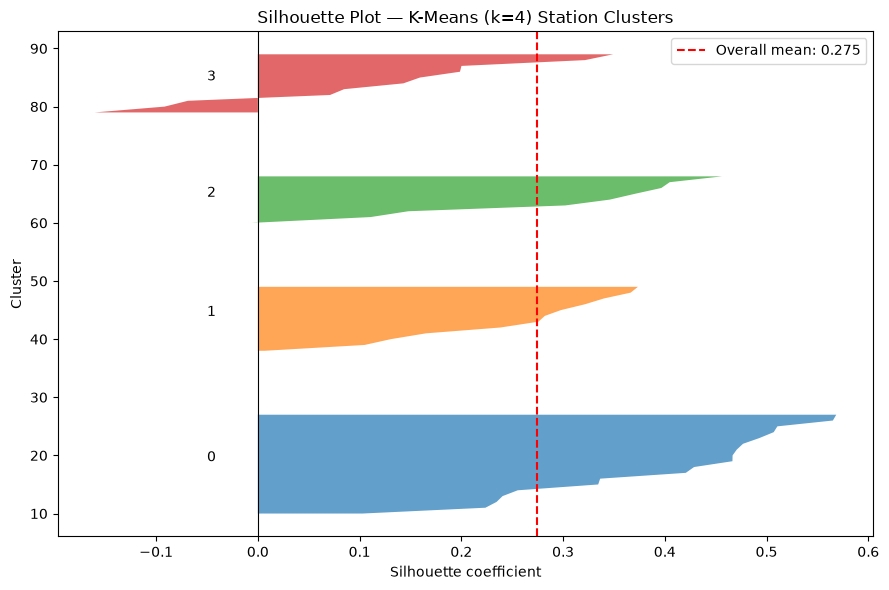

In [76]:
# silhouette plot (per-cluster visual):
fig, ax = plt.subplots(figsize=(9, 6))
y_lower = 10

for cluster_id in sorted(set(kmeans_final_labels)):
    cluster_sil = np.sort(sample_silhouettes[kmeans_final_labels == cluster_id])
    size = len(cluster_sil)
    y_upper = y_lower + size

    color = plt.cm.tab10(cluster_id)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, facecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(cluster_id))
    y_lower = y_upper + 10

ax.axvline(x=observed_score, color="red", linestyle="--", label=f"Overall mean: {observed_score:.3f}")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot — K-Means (k=4) Station Clusters")
ax.legend()
plt.tight_layout()
plt.show()

## Cluster Quality Evaluation

| Method | Silhouette | Davies-Bouldin | Calinski-Harabasz | Notes |
|---|---|---|---|---|
| K-Means (k=4) | 0.275 | 1.119 | 18.9 | **Primary model** |
| Hierarchical - Ward (k=4) | 0.240 | - | - | Secondary validation |
| Hierarchical - Average (k=4) | 0.264 | - | - | - |
| Hierarchical - Complete (k=4) | 0.157 | - | - | - |
| DBSCAN (best eps tested) | - | - | - | No usable parameter setting found |

K-Means (k=4) remains the best-performing configuration on silhouette among all tested methods.
The Calinski-Harabasz index (18.9) is modest in absolute terms but is consistent with the FAIR
(not GOOD/EXCELLENT) quality rating already established via the professional-threshold assessment
in Milestone 4 no metric here contradicts that earlier conclusion.

### Per-Cluster Silhouette Breakdown

| Cluster | Size | Mean Silhouette | Min Silhouette | Negative Points |
|---|---|---|---|---|
| 0 | 18 | 0.395 | 0.103 | 0 (0%) |
| 1 | 12 | 0.242 | 0.007 | 0 (0%) |
| 2 | 9 | 0.281 | -0.006 | 1 (11%) |
| 3 | 11 | 0.110 | -0.160 | 3 (27%) |

This is a meaningfully more precise result than the single aggregate silhouette score (0.275)
suggested. **Cluster 0 is genuinely well-formed**  every station in it fits better with its own
cluster than any alternative. **Cluster 3 is the weak point of this solution**: its mean
silhouette (0.110) is well below the FAIR threshold on its own, and over a quarter of its member
stations have negative silhouette values, meaning those specific stations are, on average, more
similar to a station in a different cluster than to the rest of Cluster 3. Clusters 1 and 2 sit in
between  acceptable but not strong.

**Implication for interpretation:** profile descriptions and any recommendations drawn from
Cluster 0 (and, with somewhat less confidence, Cluster 2) can be stated with reasonable confidence.
Cluster 3's profile should be described more cautiously  as a "loosely grouped" or "catch-all"
profile rather than a sharply defined one  and any station-level conclusions drawn from its
3 borderline members should be flagged as uncertain rather than firm. This refines, with concrete
per-cluster evidence, the general caution already established by the low bootstrap ARI stability
(0.431) in Milestone 5

## Cluster Visualizations

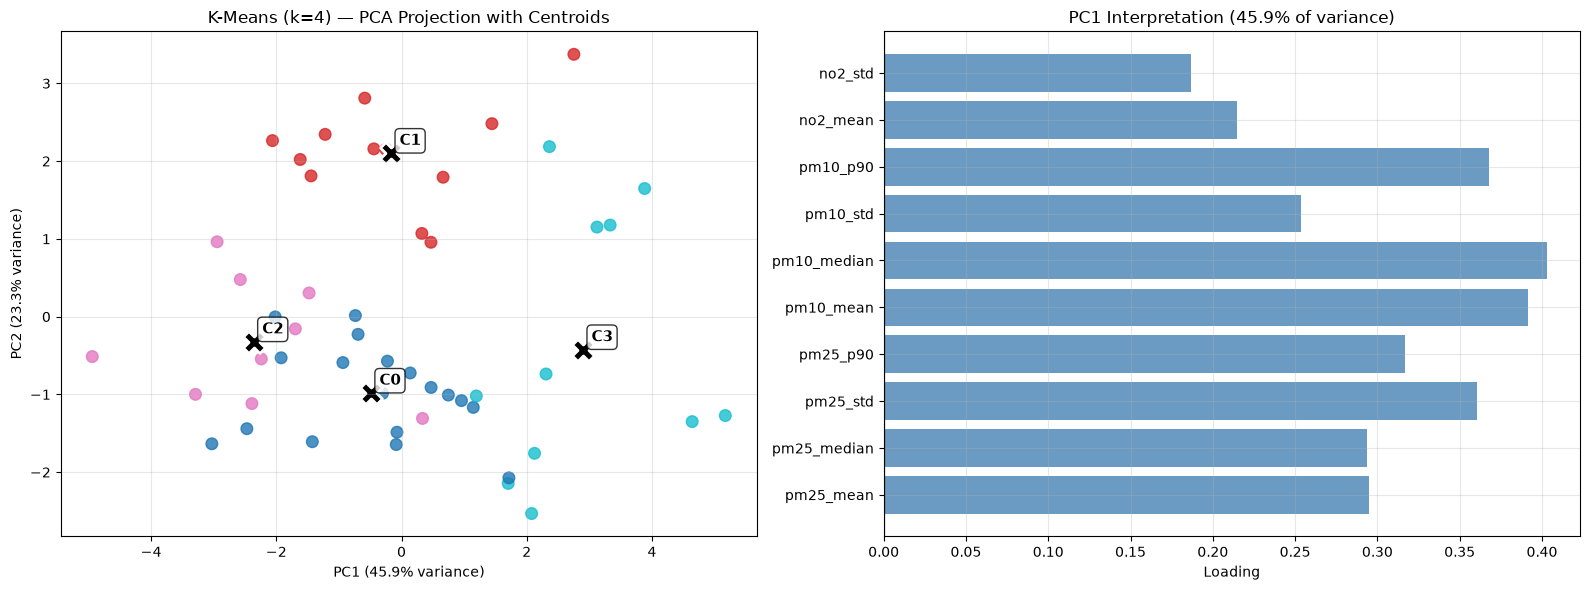

In [77]:
# PCA with centroids and component-loading interpretation:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca_2d.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: scatter with centroids
ax1 = axes[0]
scatter = ax1.scatter(pca_coords[:, 0], pca_coords[:, 1], c=kmeans_final_labels,
                       cmap="tab10", s=70, alpha=0.8)
for cluster_id in sorted(set(kmeans_final_labels)):
    mask = kmeans_final_labels == cluster_id
    centroid = pca_coords[mask].mean(axis=0)
    ax1.scatter(*centroid, c="black", s=250, marker="X", edgecolors="white", linewidth=2)
    ax1.annotate(f"C{cluster_id}", centroid, xytext=(6, 6), textcoords="offset points",
                 fontsize=11, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax1.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
ax1.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
ax1.set_title("K-Means (k=4) — PCA Projection with Centroids")
ax1.grid(True, alpha=0.3)

# Panel 2: PC1 loadings (which features drive the main axis of separation)
pc1_loadings = pca_2d.components_[0]
colors = ["crimson" if v < 0 else "steelblue" for v in pc1_loadings]
ax2 = axes[1]
ax2.barh(CLUSTERING_FEATURES, pc1_loadings, color=colors, alpha=0.8)
ax2.axvline(x=0, color="black", linewidth=0.8)
ax2.set_xlabel("Loading")
ax2.set_title(f"PC1 Interpretation ({pca_2d.explained_variance_ratio_[0]:.1%} of variance)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

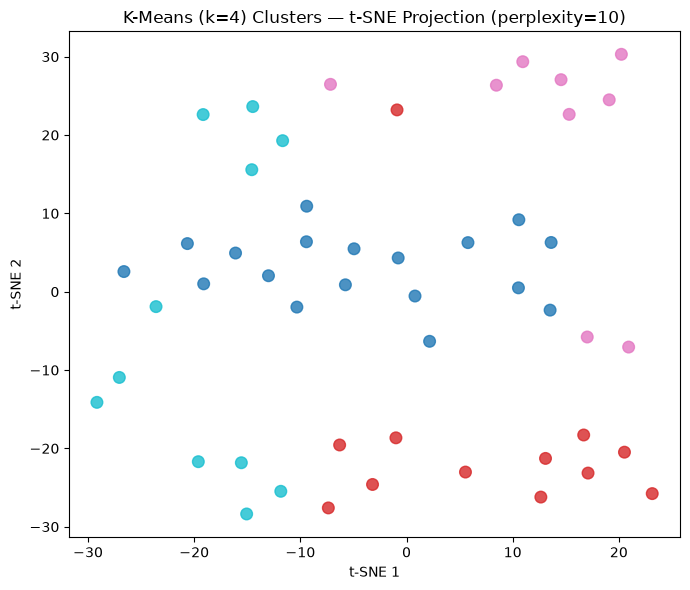

In [78]:
# t-SNE as a nonlinear cross-check (perplexity scaled down for n=50):
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=10, max_iter=1000)
tsne_coords = tsne.fit_transform(X)

plt.figure(figsize=(7, 6))
plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=kmeans_final_labels, cmap="tab10", s=70, alpha=0.8)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("K-Means (k=4) Clusters — t-SNE Projection (perplexity=10)")
plt.tight_layout()
plt.show()

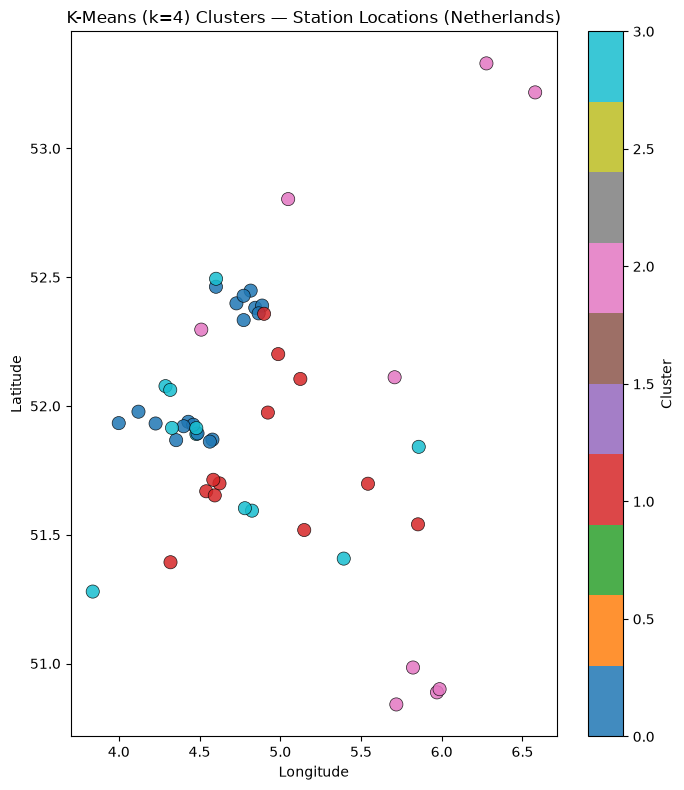

In [79]:
# geographic map (station lat/lon from Milestone 2 metadata, unused until now):
station_coords = raw_locations.set_index("meetlocatie_id")[["breedtegraad", "lengtegraad"]]
plot_coords = station_coords.loc[station_features_clustering.index]

plt.figure(figsize=(7, 8))
scatter = plt.scatter(plot_coords["lengtegraad"], plot_coords["breedtegraad"],
                       c=kmeans_final_labels, cmap="tab10", s=90, alpha=0.85, edgecolors="black", linewidth=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means (k=4) Clusters — Station Locations (Netherlands)")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

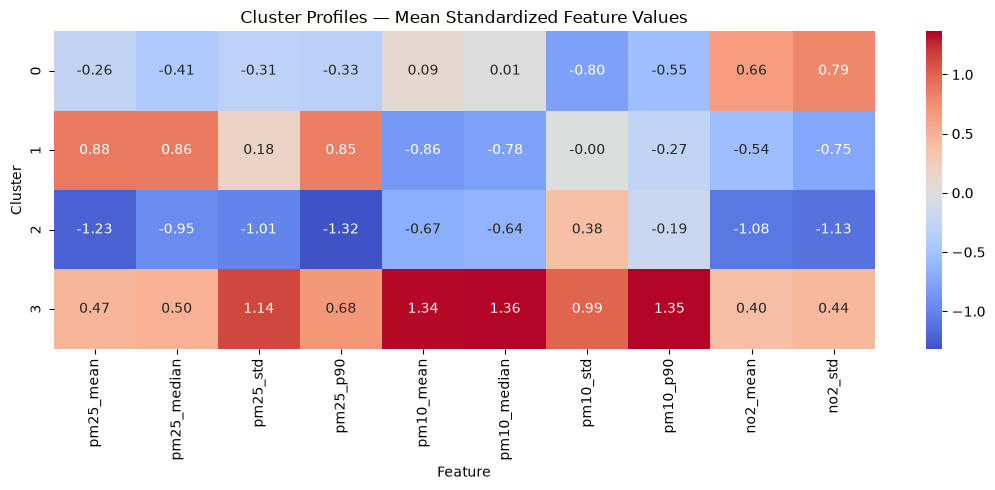

In [80]:
# cluster profile heatmap (standardized features by cluster mean):
profile_df = station_features_scaled.copy()
profile_df["cluster"] = kmeans_final_labels
cluster_means_scaled = profile_df.groupby("cluster")[CLUSTERING_FEATURES].mean()

plt.figure(figsize=(11, 5))
sns.heatmap(cluster_means_scaled, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Cluster Profiles — Mean Standardized Feature Values")
plt.xlabel("Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

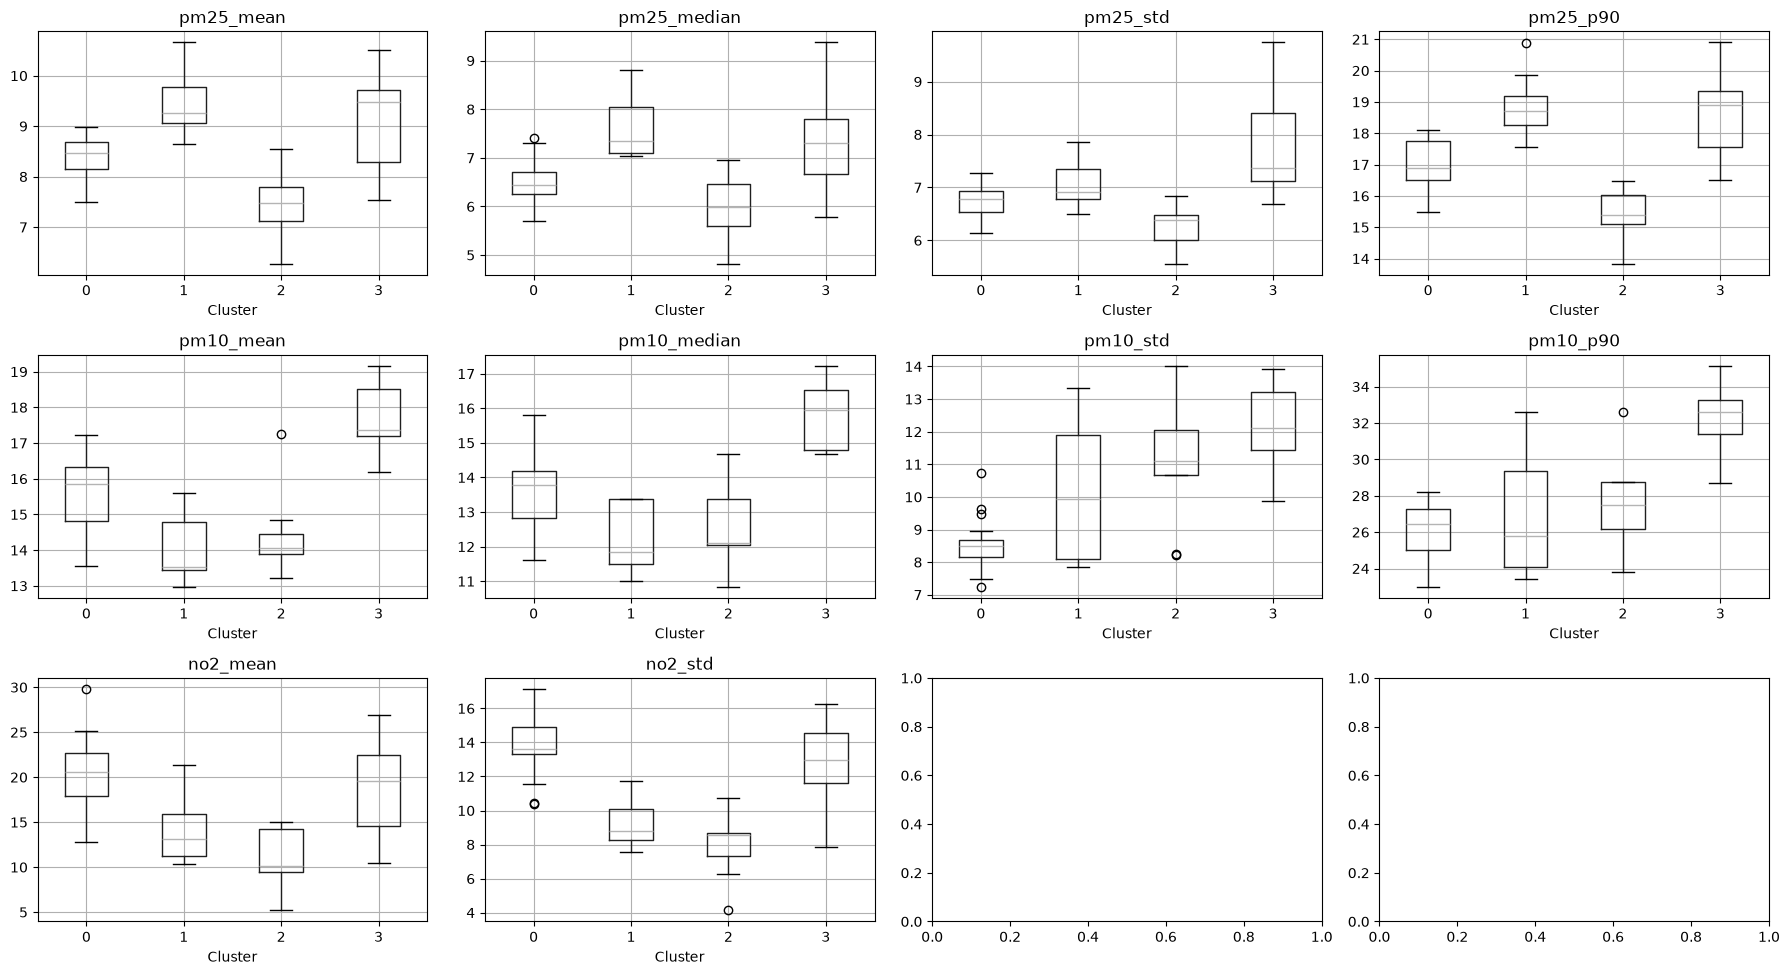

In [81]:
#  boxplots of unscaled features per cluster (real µg/m³ units):
unscaled_df = station_features_primary[CLUSTERING_FEATURES].copy()
unscaled_df["cluster"] = kmeans_final_labels

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.ravel()
for i, col in enumerate(CLUSTERING_FEATURES):
    unscaled_df.boxplot(column=col, by="cluster", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Cluster")
plt.suptitle("")
plt.tight_layout()
plt.show()

## Cluster Profiles & Patterns

PC1 (45.9% of variance) is dominated by PM10 and PM2.5 statistics (loadings 0.32-0.40), with NO2
contributing much less (0.19-0.22)  meaning the primary axis separating stations is overall
particulate intensity, not traffic-specific signal. NO2 mainly distinguishes clusters along a
secondary axis, visible in the standardized-mean heatmap rather than in the PC1 bar chart alone.

### Cluster 0  "Traffic-Influenced, Lower Particulate" (n=18, strongest cluster: silhouette 0.395)
The only cluster with **positive standardized NO2** (mean +0.66, std +0.79) while sitting negative
on nearly all PM2.5/PM10 measures. Geographically concentrated in the western/central Randstad 
consistent with urban, traffic-dense monitoring locations. This matches the "traffic-influenced,
high-NO2" profile hypothesized in the Milestone 1 proposal.

### Cluster 1  "PM2.5-Dominant" (n=12, silhouette 0.242)
High PM2.5 across every statistic (mean +0.88, median +0.86, p90 +0.85) but *negative* PM10 and
NO2  a profile decoupled from local traffic. This doesn't match a single pre-specified hypothesis
category cleanly; it suggests a fine-particulate-specific pattern (potentially regional or
secondary aerosol formation) distinct from the coarser PM10/traffic story.

### Cluster 2  "Low-Pollution Background" (n=9, silhouette 0.281)
Negative across nearly every feature  the clearest match to the hypothesized "background/rural"
profile. Notably the most geographically dispersed cluster, including far-north coastal and
southern stations rather than one region  consistent with background monitoring sites placed
deliberately away from major pollution sources nationwide, not with a single regional pattern.

### Cluster 3  "Mixed High-Pollution" (n=11, weakest cluster: silhouette 0.110, 27% negative points)
Elevated on nearly every feature simultaneously (PM10 mean +1.34, median +1.36, p90 +1.35; PM2.5
also elevated)  matching the "mixed high-pollution" profile hypothesized at the outset. However,
unlike Cluster 0's clear regional concentration, this cluster's stations are geographically
scattered with no visible regional pattern, and the t-SNE projection shows its points splitting
into two separated groups rather than forming one cohesive cloud. **This directly corroborates the
low silhouette (0.110) and low bootstrap stability (ARI 0.431) found earlier**  Cluster 3 groups
stations that share a high absolute pollution level without sharing a clear common driver or
location, making it the least reliable of the four profiles for confident interpretation.

### Connection to the original hypothesis
The Milestone 1 hypothesis anticipated traffic-influenced, particulate-dominated, background, and
mixed-high-pollution profiles  three of these (Clusters 0, 2, and 3) map reasonably well onto that
framing. The hypothesized "ozone-influenced" cluster did not emerge, which is expected: O3 was
deliberately excluded from the primary clustering features (Milestone 2) due to limited coverage,
so no cluster could be defined by it. Cluster 1 (PM2.5-dominant, traffic-decoupled) was not
explicitly anticipated and is the most novel finding of this analysis  worth flagging as an
unexpected pattern rather than folding it into one of the pre-specified categories.

### Which clusters warrant closest attention
**Cluster 3** is the strongest candidate for a genuine "potential hotspot" signal  its stations
show the highest absolute pollution across nearly every pollutant  but given its low internal
cohesion, it should be treated as a starting point for further investigation (e.g. individual
station review) rather than a confirmed, unified group. **Cluster 0** offers the most confident,
actionable pattern (well-formed, geographically coherent, matches known urban/traffic dynamics),
making it the best candidate for targeted, evidence-based traffic-related intervention discussions.

In [82]:
# spatial coherence per cluster (formalizes the map observation):
from sklearn.neighbors import NearestNeighbors

def spatial_coherence(coords, labels, n_neighbors=5):
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(coords)
    _, indices = nbrs.kneighbors(coords)

    coherence = {}
    for cluster_id in sorted(set(labels)):
        cluster_idx = np.where(labels == cluster_id)[0]
        same_cluster_count, total = 0, 0
        for idx in cluster_idx:
            neighbor_idx = indices[idx][1:]  # exclude self
            same_cluster_count += np.sum(labels[neighbor_idx] == cluster_id)
            total += len(neighbor_idx)
        coherence[cluster_id] = same_cluster_count / total
    return coherence

coords_array = plot_coords[["lengtegraad", "breedtegraad"]].values
coherence_scores = spatial_coherence(coords_array, kmeans_final_labels)
for cluster_id, score in coherence_scores.items():
    print(f"Cluster {cluster_id}: spatial coherence = {score:.3f}")

Cluster 0: spatial coherence = 0.689
Cluster 1: spatial coherence = 0.483
Cluster 2: spatial coherence = 0.400
Cluster 3: spatial coherence = 0.182


In [83]:
# Cohen's d effect sizes for top distinguishing features per cluster:
def cluster_effect_sizes(df_scaled, labels, features):
    results = {}
    for cluster_id in sorted(set(labels)):
        mask = labels == cluster_id
        in_cluster = df_scaled.loc[mask, features]
        out_cluster = df_scaled.loc[~mask, features]

        effect_sizes = {}
        for feat in features:
            pooled_std = np.sqrt(((in_cluster[feat].var() * (mask.sum() - 1)) +
                                   (out_cluster[feat].var() * ((~mask).sum() - 1))) /
                                  (len(df_scaled) - 2))
            d = (in_cluster[feat].mean() - out_cluster[feat].mean()) / pooled_std
            effect_sizes[feat] = d
        results[cluster_id] = pd.Series(effect_sizes).sort_values(key=abs, ascending=False)
    return results

effect_sizes = cluster_effect_sizes(station_features_scaled, kmeans_final_labels, CLUSTERING_FEATURES)
for cluster_id, sizes in effect_sizes.items():
    print(f"\nCluster {cluster_id} — top distinguishing features (Cohen's d):")
    print(sizes.head(3))


Cluster 0 — top distinguishing features (Cohen's d):
pm10_std   -1.519961
no2_std     1.510932
no2_mean    1.161227
dtype: float64

Cluster 1 — top distinguishing features (Cohen's d):
pm25_mean      1.305467
pm25_median    1.271113
pm10_mean     -1.268225
dtype: float64

Cluster 2 — top distinguishing features (Cohen's d):
pm25_p90    -2.000018
pm25_mean   -1.792827
no2_std     -1.586153
dtype: float64

Cluster 3 — top distinguishing features (Cohen's d):
pm10_median    2.487137
pm10_p90       2.430862
pm10_mean      2.381039
dtype: float64


### Spatial Coherence

| Cluster | Spatial Coherence (5-NN) |
|---|---|
| 0 | 0.689 |
| 1 | 0.483 |
| 2 | 0.400 |
| 3 | 0.182 |

Cluster 0 is clearly the most geographically coherent group  roughly 69% of its stations' nearest
neighbors belong to the same cluster, consistent with its concentration in the Randstad urban
corridor. Cluster 3 is the least coherent by a wide margin (0.182)  confirming quantitatively
what the map and t-SNE plot suggested visually: its member stations do not share a common
location, only a common pollution *level*.



### Effect Sizes (Cohen's d)  What Statistically Distinguishes Each Cluster

| Cluster | Top distinguishing features (\|d\|) |
|---|---|
| 0 | no2_std (+1.51, large), no2_mean (+1.16, large), pm10_std (-1.52, large) |
| 1 | pm25_mean (+1.31, large), pm25_median (+1.27, large), pm10_mean (-1.27, large) |
| 2 | pm25_p90 (-2.00, large), pm25_mean (-1.79, large), no2_std (-1.59, large) |
| 3 | pm10_median (+2.49, large), pm10_p90 (+2.43, large), pm10_mean (+2.38, large) |

All four clusters show large effect sizes (conventionally, |d| > 0.8 is "large") on their top
features  meaning each cluster is statistically distinct from the rest of the dataset on average
pollution characteristics, even where internal cohesion (silhouette, spatial coherence) is weaker.
This resolves an apparent tension: Cluster 3's stations share an extreme, statistically distinct
PM10 signature (large effect size), but do not form a tight, internally consistent, or
geographically bounded group (low silhouette, low spatial coherence). It is best understood as
"stations with unusually high particulate levels, wherever they occur" rather than a single
regional or source-driven phenomenon.



### Final Cluster Labels

| Cluster | Label | Rationale |
|---|---|---|
| 0 | **Traffic-Influenced, Lower-Particulate** | Elevated NO2 (mean, std), reduced PM10 std; spatially coherent (0.689), concentrated in the Randstad; strongest internal cohesion (silhouette 0.395) |
| 1 | **PM2.5-Dominant, Traffic-Decoupled** | Elevated PM2.5 (mean, median), reduced PM10; moderate coherence (0.483); a novel pattern not anticipated in the original hypothesis |
| 2 | **Low-Pollution Background** | Strongly negative on PM2.5 and NO2 std (large negative effect sizes); most consistent with rural/background monitoring sites; dispersed nationwide rather than regional |
| 3 | **Elevated Particulate Outliers (Mixed, Low-Cohesion)** | Extreme PM10 elevation (largest effect sizes of any cluster) but the weakest internal cohesion and lowest spatial coherence (0.182)  a statistically real but structurally loose grouping; individual stations warrant closer, case-by-case review rather than being treated as one coherent "hotspot region" |

## Impact Brief (for Non-Technical Stakeholders)


**The question we started with.** Air pollution in the Netherlands isn't the same everywhere, and a
single national average hides that. Two locations could report the "same" average pollution level
while one sits next to a busy motorway and the other sits in open countryside  same number, very
different reality, and possibly a very different health risk for the people living there. This
project asked: if we stop looking at one national number and instead look at each monitoring
station's *full mix* of pollutants, do stations naturally sort into recognizable "types"  a
traffic type, a background type, a heavily-polluted type  and if so, which stations fall into which?

**Getting the data ready ,why only 50 of 515 stations?** The Dutch national air-monitoring network
(RIVM Luchtmeetnet) has 515 station locations, but not every station measures every pollutant, and
not every station has a full, reliable year of readings. We started with four pollutants (fine
particulates PM2.5, coarser particulates PM10, traffic-linked NO2, and ozone O3), but requiring a
station to have good data on *all four* left only 26 usable stations  too few to trust a grouping
built on them. Instead, we kept the three pollutants (PM2.5, PM10, NO2) that the most stations
measure well, and required each station to have data for at least 75% of the hours in 2024. That
left **50 stations**  enough to work with, while still being honest that this is a sample, not
the full network. Ozone was set aside from the grouping itself, but we still checked it afterward
for extra context.

Two data-cleaning judgment calls are worth knowing about, because they affect how much to trust the
numbers:
- A small share of readings across all four pollutants were *slightly negative*  a normal
  side-effect of sensors operating near their detection limit, not a data error. These were reset
  to zero rather than deleted, so as not to accidentally bias the results toward higher pollution
  than is real.
- One station (NL53016) reported PM10 readings over 1,000 µg/m³  more than 50 times its normal
  range  sustained almost without change for more than a day. Real pollution spikes fluctuate
  hour to hour; this pattern looks like a stuck or broken sensor, not a real air-quality event. Those
  specific readings were excluded network-wide (the same rule applied to every station, not just
  this one), which fixed a distortion that would otherwise have thrown off that station's whole
  profile.

**How we grouped the stations.** This is "unsupervised" analysis  there's no existing answer key
saying which station belongs to which pollution "type," so the goal was to let the data reveal
natural groupings rather than sort stations into categories decided in advance. Before committing to
a method, we ran a check (the "Hopkins statistic," a test for whether a dataset actually has
group-like structure at all, versus being one smooth continuum with no real seams). The result was
mixed  some real structure, but not sharply defined  which we treated as an honest early warning
that any grouping found later would likely be a soft pattern, not hard, clean-edged categories.

We then tried **three different grouping methods** and compared them honestly:
- **K-Means** (sorts stations into a chosen number of round, similarly-sized groups)  this became
  the primary method.
- **DBSCAN** (designed to find naturally dense clumps separated by empty gaps, and to flag outliers
  as "noise" rather than force them into a group)  this method **could not find any usable, stable
  grouping** in this data, no matter how its settings were adjusted. That's not a failure of the
  analysis; it's itself informative  it confirms the stations form more of a continuum than sharply
  separated islands.
- **Hierarchical clustering** (builds a nested tree of similarity, like a family tree of stations) 
  used as a cross-check rather than the main method. It largely agreed with K-Means' split into four
  groups, which is reassuring: two different methods pointed toward a similar answer.

For K-Means, we tested splitting the stations into anywhere from 2 to 8 groups. **Four groups**
gave the best-balanced, most defensible result (18, 12, 9, and 11 stations respectively). Splitting
into more groups looked marginally better on paper, but under inspection those extra groups were
just isolating one or two unusual stations rather than finding a real, repeatable pattern  a
well-known pitfall when the sample is small.

**How much should you trust these four groups?** We ran several independent checks, and they don't
all agree  which is itself the honest answer:
- ✅ **Is this grouping real, or did the method just imagine patterns in randomness?** We tested this
  directly by comparing the result against 1,000 randomly shuffled versions of the data. The real
  grouping outperformed every single random version. **This is real structure, not a coincidence.**
- ⚠️ **Would we get the same four groups if we had slightly different stations in the sample?** Here
  the answer is more cautious. Re-running the analysis on many random resamples of the 50 stations
  showed that group boundaries shift more than we'd like  especially for stations near the edge of
  a group. In practical terms: **which group a borderline station belongs to should be treated as a
  reasonable estimate, not a permanent label.**
- The upshot, applied per group below: some groups (especially the traffic-linked one) are
  well-formed and consistent; others (especially the "elevated particulate" group) are statistically
  real but loosely defined, and individual stations in them deserve a second look before any decision
  is based on their membership.

### The Four Profiles We Found

| Profile (plain-language name) | Stations | How confident are we? | What makes it distinct |
|---|---|---|---|
| **Traffic-Influenced, Lower-Particulate** | 18 | **High**  the best-formed, most consistent group | The only profile with a clearly elevated traffic-linked pollutant (NO2); concentrated almost entirely in the Randstad (Amsterdam–Rotterdam–The Hague–Utrecht corridor) |
| **PM2.5-Dominant, Traffic-Decoupled** | 12 | **Medium** | Elevated fine-particulate pollution *without* the traffic signal  a pattern nobody predicted going in, suggesting a different, non-traffic source (regional transport of pollution, agriculture, wood burning, etc. are plausible, but this data can't say which) |
| **Low-Pollution Background** | 9 | **Medium** | The cleanest profile across the board; scattered nationwide rather than tied to one region  consistent with rural/background monitoring sites |
| **Elevated Particulate Outliers** | 11 | **Low** | The most polluted profile on paper (highest coarse-particulate levels), but the least internally consistent group  over a quarter of its stations arguably fit another group better. Best read as "individually elevated stations worth investigating," not a single coherent hotspot region |

Three of these four match what we expected going in (a traffic type, a background type, a
heavily-polluted type). The fourth  a fine-particulate profile with no traffic connection  was not
anticipated, and is the most genuinely new finding of this analysis. We had also expected a possible
"ozone-influenced" profile, but ozone wasn't included in the grouping itself (too few stations
measured it reliably), so no such group could emerge  a limitation to be transparent about, not a
finding that ozone doesn't matter.

### Back to the Original Question

This answers the question the project set out to ask: national averages *were* hiding real
differences. A station in the Traffic-Influenced group and a station in the Low-Pollution Background
group could, in principle, report similar-looking single-pollutant numbers on any given day while
facing a fundamentally different year-round exposure pattern. Knowing which profile a station
belongs to  and how confident we can be in that label  gives agencies, municipalities, and
health organizations a more honest starting point than one national number ever could.